In [3]:
library(data.table)
library(ranger)
library(fastshap)
library(ggplot2)

# =========================================================
# SHAP PER SITE (Option A: one global model, then aggregate by site)
# =========================================================

# ---------------------------------------------------------
# 1) Load data
# ---------------------------------------------------------

dt <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv")

cat("Loaded dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

# add IGBP if missing
if (!("IGBP" %in% names(dt))) {
  meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, year, IGBP)]
  meta_dt <- unique(meta_dt)
  dt <- merge(dt, meta_dt, by = c("SITE_ID", "year"), all.x = TRUE)
}

cat("Rows after adding IGBP (if needed):", nrow(dt), "\n")

# ---------------------------------------------------------
# 2) Define responses
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

# ---------------------------------------------------------
# 3) Define predictor groups
# ---------------------------------------------------------

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3112)","Leaf area","Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

deadwood_vars <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m","loss_mean_pp_500m","loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")
memory_vars <- readLines("derived_tables/vars_anomlag12_master_3yr.txt")

trait_vars    <- trait_vars[trait_vars %in% names(dt)]
deadwood_vars <- deadwood_vars[deadwood_vars %in% names(dt)]
lag24_vars    <- lag24_vars[lag24_vars %in% names(dt)]
memory_vars   <- memory_vars[memory_vars %in% names(dt)]

all_predictors <- unique(c(lag24_vars, trait_vars, deadwood_vars, memory_vars))

cat("Predictor group sizes:\n")
cat("Meteo   :", length(lag24_vars), "\n")
cat("Traits  :", length(trait_vars), "\n")
cat("Deadwood:", length(deadwood_vars), "\n")
cat("Memory  :", length(memory_vars), "\n")

# ---------------------------------------------------------
# 4) Variable -> group lookup
# ---------------------------------------------------------

group_map <- data.table(variable = all_predictors)

group_map[, group := fifelse(variable %in% lag24_vars, "Meteo",
                      fifelse(variable %in% trait_vars, "Traits",
                      fifelse(variable %in% deadwood_vars, "Deadwood",
                      fifelse(variable %in% memory_vars, "Memory",
                      "Other"))))]

# ---------------------------------------------------------
# 5) Function: compute SHAP per site for one response
# ---------------------------------------------------------

compute_shap_per_site <- function(data_subset,
                                  response_var,
                                  nsim = 10,
                                  num_trees = 500,
                                  min_rows = 50,
                                  min_sites = 10) {
  
  needed_cols <- c("SITE_ID", "year", "IGBP", response_var, all_predictors)
  needed_cols <- needed_cols[needed_cols %in% names(data_subset)]
  
  d <- copy(data_subset)[, ..needed_cols]
  d <- d[complete.cases(d)]
  
  n_rows <- nrow(d)
  n_sites <- uniqueN(d$SITE_ID)
  
  cat("Running SHAP per site | response =", response_var,
      "| rows =", n_rows,
      "| sites =", n_sites, "\n")
  
  if (n_rows < min_rows || n_sites < min_sites) {
    cat(" -> skipped\n")
    return(NULL)
  }
  
  xvars <- setdiff(names(d), c("SITE_ID", "year", "IGBP", response_var))
  if (length(xvars) == 0) return(NULL)
  
  X <- d[, ..xvars]
  y <- d[[response_var]]
  
  rf_fit <- ranger(
    x = X,
    y = y,
    num.trees = num_trees,
    seed = 42,
    respect.unordered.factors = "order",
    write.forest = TRUE
  )
  
  pred_fun <- function(object, newdata) {
    predict(object, data = newdata)$predictions
  }
  
  shap_mat <- fastshap::explain(
    object = rf_fit,
    X = X,
    pred_wrapper = pred_fun,
    nsim = nsim,
    adjust = TRUE
  )
  
  shap_dt <- as.data.table(shap_mat)
  shap_dt[, SITE_ID := d$SITE_ID]
  shap_dt[, IGBP := d$IGBP]
  
  shap_long <- melt(
    shap_dt,
    id.vars = c("SITE_ID", "IGBP"),
    measure.vars = setdiff(names(shap_dt), c("SITE_ID", "IGBP")),
    variable.name = "variable",
    value.name = "shap"
  )
  
  shap_long <- merge(shap_long, group_map, by = "variable", all.x = TRUE)
  
  shap_site <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = .(SITE_ID, IGBP, group)]
  
  shap_site[, rel_importance := mean_abs_shap / sum(mean_abs_shap), by = SITE_ID]
  shap_site[, response := response_var]
  
  setcolorder(shap_site, c("SITE_ID", "IGBP", "response", "group",
                           "mean_abs_shap", "rel_importance"))
  
  return(shap_site)
}

# ---------------------------------------------------------
# 6) Run for all EFPs
# ---------------------------------------------------------

shap_site_list <- list()

for (resp in response_vars) {
  shap_site_list[[resp]] <- compute_shap_per_site(
    data_subset = dt,
    response_var = resp,
    nsim = 10,      # increase later if needed
    num_trees = 500,
    min_rows = 50,
    min_sites = 10
  )
}

shap_per_site <- rbindlist(shap_site_list, fill = TRUE)

# ---------------------------------------------------------
# 7) Save main table
# ---------------------------------------------------------

fwrite(shap_per_site, "derived_tables/shap_per_site.csv")

cat("\nSaved:\n")
cat("- derived_tables/shap_per_site.csv\n")

# ---------------------------------------------------------
# 8) Summaries
# ---------------------------------------------------------

# overall grouped site average
shap_site_summary <- shap_per_site[, .(
  mean_rel_importance = mean(rel_importance, na.rm = TRUE),
  sd_rel_importance = sd(rel_importance, na.rm = TRUE),
  n_sites = uniqueN(SITE_ID)
), by = .(response, group)]

fwrite(shap_site_summary, "derived_tables/shap_per_site_summary.csv")

# by IGBP
shap_site_igbp <- shap_per_site[, .(
  mean_rel_importance = mean(rel_importance, na.rm = TRUE),
  sd_rel_importance = sd(rel_importance, na.rm = TRUE),
  n_sites = uniqueN(SITE_ID)
), by = .(response, IGBP, group)]

fwrite(shap_site_igbp, "derived_tables/shap_per_site_by_igbp.csv")

cat("- derived_tables/shap_per_site_summary.csv\n")
cat("- derived_tables/shap_per_site_by_igbp.csv\n")

# ---------------------------------------------------------
# 9) Plots
# ---------------------------------------------------------

# Plot A: per-site distribution by EFP
p1 <- ggplot(shap_per_site, aes(x = group, y = rel_importance, fill = group)) +
  geom_boxplot() +
  facet_wrap(~response, scales = "free_y") +
  theme_minimal(base_size = 14) +
  labs(
    title = "Relative SHAP importance per site by EFP",
    x = "",
    y = "Relative importance"
  )

ggsave("derived_tables/plot_shap_per_site_by_efp.png", p1, width = 10, height = 7, dpi = 300)

# Plot B: per-site distribution by EFP and IGBP
p2 <- ggplot(shap_per_site, aes(x = group, y = rel_importance, fill = group)) +
  geom_boxplot() +
  facet_grid(response ~ IGBP, scales = "free_y") +
  theme_minimal(base_size = 11) +
  labs(
    title = "Relative SHAP importance per site by EFP and IGBP",
    x = "",
    y = "Relative importance"
  )

ggsave("derived_tables/plot_shap_per_site_by_efp_igbp.png", p2, width = 16, height = 10, dpi = 300)

# Plot C: mean grouped SHAP by IGBP
p3 <- ggplot(shap_site_igbp, aes(x = group, y = mean_rel_importance, fill = group)) +
  geom_col() +
  facet_grid(response ~ IGBP, scales = "free_y") +
  theme_minimal(base_size = 11) +
  labs(
    title = "Mean relative SHAP importance by EFP and IGBP",
    x = "",
    y = "Mean relative importance"
  )

ggsave("derived_tables/plot_shap_mean_by_efp_igbp.png", p3, width = 16, height = 10, dpi = 300)

cat("\nSaved plots:\n")
cat("- derived_tables/plot_shap_per_site_by_efp.png\n")
cat("- derived_tables/plot_shap_per_site_by_efp_igbp.png\n")
cat("- derived_tables/plot_shap_mean_by_efp_igbp.png\n")

Loaded dataset: 156 rows x 335 cols
Rows after adding IGBP (if needed): 156 
Predictor group sizes:
Meteo   : 288 
Traits  : 21 
Deadwood: 8 
Memory  : 8 
Running SHAP per site | response = uWUE | rows = 156 | sites = 52 
Running SHAP per site | response = ETmax | rows = 156 | sites = 52 
Running SHAP per site | response = GPPsat | rows = 156 | sites = 52 
Running SHAP per site | response = NEPmax | rows = 156 | sites = 52 

Saved:
- derived_tables/shap_per_site.csv
- derived_tables/shap_per_site_summary.csv
- derived_tables/shap_per_site_by_igbp.csv

Saved plots:
- derived_tables/plot_shap_per_site_by_efp.png
- derived_tables/plot_shap_per_site_by_efp_igbp.png
- derived_tables/plot_shap_mean_by_efp_igbp.png


In [1]:
###Shap per site without memory
library(data.table)
library(ranger)
library(fastshap)
library(ggplot2)

# =========================================================
# SHAP PER SITE (NO MEMORY)
# one global model, then aggregate by site
# =========================================================

# ---------------------------------------------------------
# 0) Output folder
# ---------------------------------------------------------

out_dir <- "derived_tables/final_results_3yr/shap_no_memory"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# ---------------------------------------------------------
# 1) Load data
# ---------------------------------------------------------

dt <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv")

cat("Loaded dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

# add IGBP if missing
if (!("IGBP" %in% names(dt))) {
  meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, year, IGBP)]
  meta_dt <- unique(meta_dt)
  dt <- merge(dt, meta_dt, by = c("SITE_ID", "year"), all.x = TRUE)
}

cat("Rows after adding IGBP (if needed):", nrow(dt), "\n")

# ---------------------------------------------------------
# 2) Define responses
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

# ---------------------------------------------------------
# 3) Define predictor groups
#    MEMORY IS EXCLUDED HERE
# ---------------------------------------------------------

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3112)","Leaf area","Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

deadwood_vars <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m","loss_mean_pp_500m","loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")

trait_vars    <- trait_vars[trait_vars %in% names(dt)]
deadwood_vars <- deadwood_vars[deadwood_vars %in% names(dt)]
lag24_vars    <- lag24_vars[lag24_vars %in% names(dt)]

all_predictors <- unique(c(lag24_vars, trait_vars, deadwood_vars))

cat("Predictor group sizes:\n")
cat("Meteo   :", length(lag24_vars), "\n")
cat("Traits  :", length(trait_vars), "\n")
cat("Deadwood:", length(deadwood_vars), "\n")

# save exact variable lists used
writeLines(lag24_vars,    file.path(out_dir, "vars_meteo_used.txt"))
writeLines(trait_vars,    file.path(out_dir, "vars_traits_used.txt"))
writeLines(deadwood_vars, file.path(out_dir, "vars_deadwood_used.txt"))

# ---------------------------------------------------------
# 4) Variable -> group lookup
# ---------------------------------------------------------

group_map <- data.table(variable = all_predictors)

group_map[, group := fifelse(variable %in% lag24_vars, "Meteo",
                      fifelse(variable %in% trait_vars, "Traits",
                      fifelse(variable %in% deadwood_vars, "Deadwood",
                      "Other")))]

# ---------------------------------------------------------
# 5) Function: compute SHAP per site for one response
# ---------------------------------------------------------

compute_shap_per_site <- function(data_subset,
                                  response_var,
                                  nsim = 10,
                                  num_trees = 500,
                                  min_rows = 50,
                                  min_sites = 10) {
  
  needed_cols <- c("SITE_ID", "year", "IGBP", response_var, all_predictors)
  needed_cols <- needed_cols[needed_cols %in% names(data_subset)]
  
  d <- copy(data_subset)[, ..needed_cols]
  d <- d[complete.cases(d)]
  
  n_rows <- nrow(d)
  n_sites <- uniqueN(d$SITE_ID)
  
  cat("Running SHAP per site | response =", response_var,
      "| rows =", n_rows,
      "| sites =", n_sites, "\n")
  
  if (n_rows < min_rows || n_sites < min_sites) {
    cat(" -> skipped\n")
    return(NULL)
  }
  
  xvars <- setdiff(names(d), c("SITE_ID", "year", "IGBP", response_var))
  if (length(xvars) == 0) return(NULL)
  
  X <- d[, ..xvars]
  y <- d[[response_var]]
  
  rf_fit <- ranger(
    x = X,
    y = y,
    num.trees = num_trees,
    seed = 42,
    respect.unordered.factors = "order",
    write.forest = TRUE
  )
  
  pred_fun <- function(object, newdata) {
    predict(object, data = newdata)$predictions
  }
  
  shap_mat <- fastshap::explain(
    object = rf_fit,
    X = X,
    pred_wrapper = pred_fun,
    nsim = nsim,
    adjust = TRUE
  )
  
  shap_dt <- as.data.table(shap_mat)
  shap_dt[, SITE_ID := d$SITE_ID]
  shap_dt[, IGBP := d$IGBP]
  
  shap_long <- melt(
    shap_dt,
    id.vars = c("SITE_ID", "IGBP"),
    measure.vars = setdiff(names(shap_dt), c("SITE_ID", "IGBP")),
    variable.name = "variable",
    value.name = "shap"
  )
  
  shap_long <- merge(shap_long, group_map, by = "variable", all.x = TRUE)
  
  shap_site <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = .(SITE_ID, IGBP, group)]
  
  shap_site[, rel_importance := mean_abs_shap / sum(mean_abs_shap), by = SITE_ID]
  shap_site[, response := response_var]
  
  setcolorder(shap_site, c("SITE_ID", "IGBP", "response", "group",
                           "mean_abs_shap", "rel_importance"))
  
  return(shap_site)
}

# ---------------------------------------------------------
# 6) Run for all EFPs
# ---------------------------------------------------------

shap_site_list <- list()

for (resp in response_vars) {
  shap_site_list[[resp]] <- compute_shap_per_site(
    data_subset = dt,
    response_var = resp,
    nsim = 10,
    num_trees = 500,
    min_rows = 50,
    min_sites = 10
  )
}

shap_per_site <- rbindlist(shap_site_list, fill = TRUE)

# ---------------------------------------------------------
# 7) Save main table
# ---------------------------------------------------------

fwrite(shap_per_site, file.path(out_dir, "shap_per_site_no_memory.csv"))

cat("\nSaved:\n")
cat("-", file.path(out_dir, "shap_per_site_no_memory.csv"), "\n")

# ---------------------------------------------------------
# 8) Summaries
# ---------------------------------------------------------

# overall grouped site average
shap_site_summary <- shap_per_site[, .(
  mean_rel_importance = mean(rel_importance, na.rm = TRUE),
  sd_rel_importance = sd(rel_importance, na.rm = TRUE),
  n_sites = uniqueN(SITE_ID)
), by = .(response, group)]

fwrite(shap_site_summary, file.path(out_dir, "shap_per_site_summary_no_memory.csv"))

# by IGBP
shap_site_igbp <- shap_per_site[, .(
  mean_rel_importance = mean(rel_importance, na.rm = TRUE),
  sd_rel_importance = sd(rel_importance, na.rm = TRUE),
  n_sites = uniqueN(SITE_ID)
), by = .(response, IGBP, group)]

fwrite(shap_site_igbp, file.path(out_dir, "shap_per_site_by_igbp_no_memory.csv"))

cat("-", file.path(out_dir, "shap_per_site_summary_no_memory.csv"), "\n")
cat("-", file.path(out_dir, "shap_per_site_by_igbp_no_memory.csv"), "\n")

# ---------------------------------------------------------
# 9) Plots
# ---------------------------------------------------------

# Plot A: per-site distribution by EFP
p1 <- ggplot(shap_per_site, aes(x = group, y = rel_importance, fill = group)) +
  geom_boxplot() +
  facet_wrap(~response, scales = "free_y") +
  theme_minimal(base_size = 14) +
  labs(
    title = "Relative SHAP importance per site by EFP (no memory)",
    x = "",
    y = "Relative importance"
  )

ggsave(file.path(out_dir, "plot_shap_per_site_by_efp_no_memory.png"),
       p1, width = 10, height = 7, dpi = 300)

# Plot B: per-site distribution by EFP and IGBP
p2 <- ggplot(shap_per_site, aes(x = group, y = rel_importance, fill = group)) +
  geom_boxplot() +
  facet_grid(response ~ IGBP, scales = "free_y") +
  theme_minimal(base_size = 11) +
  labs(
    title = "Relative SHAP importance per site by EFP and IGBP (no memory)",
    x = "",
    y = "Relative importance"
  )

ggsave(file.path(out_dir, "plot_shap_per_site_by_efp_igbp_no_memory.png"),
       p2, width = 16, height = 10, dpi = 300)

# Plot C: mean grouped SHAP by IGBP
p3 <- ggplot(shap_site_igbp, aes(x = group, y = mean_rel_importance, fill = group)) +
  geom_col() +
  facet_grid(response ~ IGBP, scales = "free_y") +
  theme_minimal(base_size = 11) +
  labs(
    title = "Mean relative SHAP importance by EFP and IGBP (no memory)",
    x = "",
    y = "Mean relative importance"
  )

ggsave(file.path(out_dir, "plot_shap_mean_by_efp_igbp_no_memory.png"),
       p3, width = 16, height = 10, dpi = 300)

cat("\nSaved plots:\n")
cat("-", file.path(out_dir, "plot_shap_per_site_by_efp_no_memory.png"), "\n")
cat("-", file.path(out_dir, "plot_shap_per_site_by_efp_igbp_no_memory.png"), "\n")
cat("-", file.path(out_dir, "plot_shap_mean_by_efp_igbp_no_memory.png"), "\n")
cat("-", file.path(out_dir, "vars_meteo_used.txt"), "\n")
cat("-", file.path(out_dir, "vars_traits_used.txt"), "\n")
cat("-", file.path(out_dir, "vars_deadwood_used.txt"), "\n")

Loaded dataset: 156 rows x 335 cols
Rows after adding IGBP (if needed): 156 
Predictor group sizes:
Meteo   : 288 
Traits  : 21 
Deadwood: 8 
Running SHAP per site | response = uWUE | rows = 156 | sites = 52 
Running SHAP per site | response = ETmax | rows = 156 | sites = 52 
Running SHAP per site | response = GPPsat | rows = 156 | sites = 52 
Running SHAP per site | response = NEPmax | rows = 156 | sites = 52 

Saved:
- derived_tables/final_results_3yr/shap_no_memory/shap_per_site_no_memory.csv 
- derived_tables/final_results_3yr/shap_no_memory/shap_per_site_summary_no_memory.csv 
- derived_tables/final_results_3yr/shap_no_memory/shap_per_site_by_igbp_no_memory.csv 

Saved plots:
- derived_tables/final_results_3yr/shap_no_memory/plot_shap_per_site_by_efp_no_memory.png 
- derived_tables/final_results_3yr/shap_no_memory/plot_shap_per_site_by_efp_igbp_no_memory.png 
- derived_tables/final_results_3yr/shap_no_memory/plot_shap_mean_by_efp_igbp_no_memory.png 
- derived_tables/final_results_

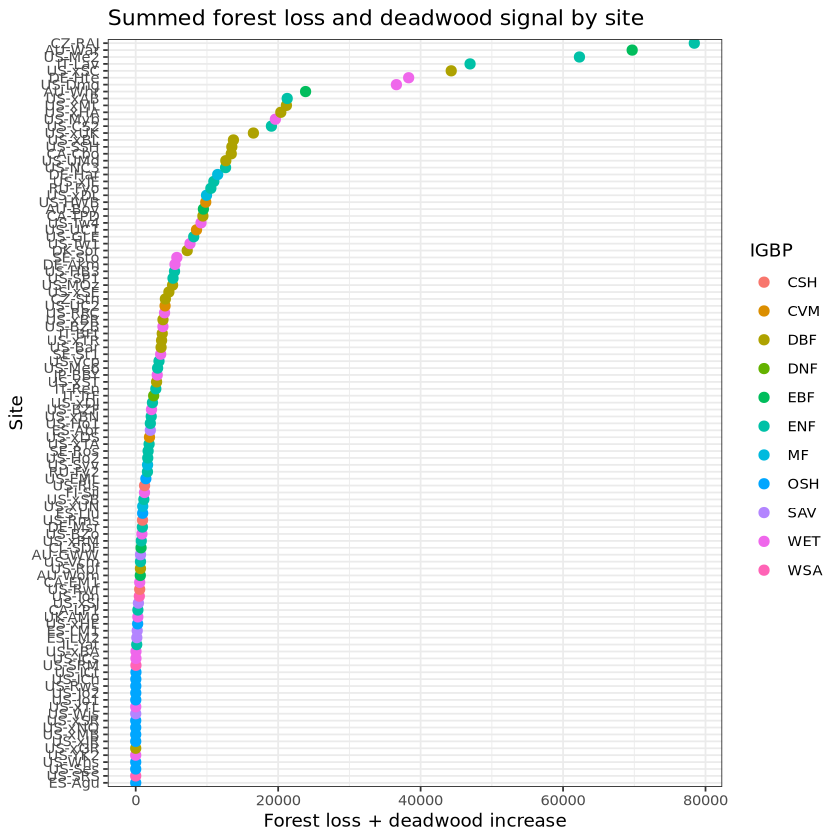

In [7]:
library(data.table)
library(ggplot2)

dt <- fread("derived_tables/modelready_FINAL_3yr.csv")

site_sum <- dt[, .(
  disturbance_sum = mean(loss_sum_pp_500m + deadwood_increase_sum_pp_500m, na.rm = TRUE),
  IGBP = first(IGBP)
), by = SITE_ID]

site_sum <- site_sum[order(disturbance_sum)]
site_sum[, SITE_ID := factor(SITE_ID, levels = SITE_ID)]

ggplot(site_sum, aes(x = disturbance_sum, y = SITE_ID, color = IGBP)) +
  geom_point(size = 2.5) +
  theme(
  axis.text.y = element_text(size = 4))+
  theme_bw(base_size = 11) +
  labs(
    title = "Summed forest loss and deadwood signal by site",
    x = "Forest loss + deadwood increase",
    y = "Site"
  )

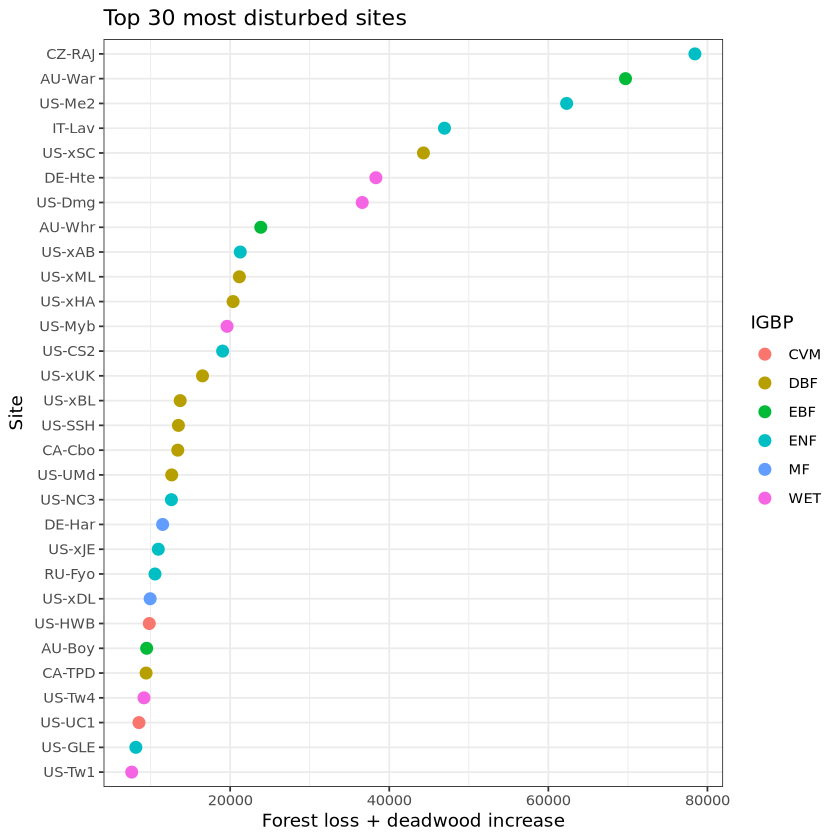

In [9]:
top_sites <- site_sum[order(-disturbance_sum)][1:30]

ggplot(top_sites, aes(x = disturbance_sum, y = reorder(SITE_ID, disturbance_sum), color = IGBP)) +
  geom_point(size = 3) +
  theme_bw() +
  labs(
    title = "Top 30 most disturbed sites",
    x = "Forest loss + deadwood increase",
    y = "Site"
  )

In [12]:
library(data.table)
library(ggplot2)

# ---------------------------------------------------------
# 1) Load data
# ---------------------------------------------------------

dt <- fread("derived_tables/modelready_FINAL_3yr.csv")

# ---------------------------------------------------------
# 2) Compute mean disturbance per site (same as before)
# ---------------------------------------------------------

site_pct <- dt[, .(
  disturbance_pct = mean(
    loss_mean_pp_500m + deadwood_increase_mean_pp_500m,
    na.rm = TRUE
  ),
  IGBP = first(IGBP)
), by = SITE_ID]

site_pct <- site_pct[!is.na(disturbance_pct)]

# ---------------------------------------------------------
# 3) Select TOP 30 most disturbed sites
# ---------------------------------------------------------

top30 <- site_pct[order(-disturbance_pct)][1:30]

# reorder for plotting (highest on top)
top30 <- top30[order(disturbance_pct)]
top30[, SITE_ID := factor(SITE_ID, levels = SITE_ID)]

# ---------------------------------------------------------
# 4) Plot
# ---------------------------------------------------------

p_top <- ggplot(top30, aes(x = disturbance_pct, y = SITE_ID, color = IGBP)) +
  geom_point(size = 3) +
  theme_bw(base_size = 12) +
  labs(
    title = "Top 30 most disturbed sites",
    x = "Mean forest loss + deadwood increase (percentage points)",
    y = "Site"
  ) +
  theme(
    axis.text.y = element_text(size = 7),
    panel.grid.minor = element_blank()
  )

# ---------------------------------------------------------
# 5) Save
# ---------------------------------------------------------

ggsave(
  "derived_tables/plot_top30_disturbance_pct.png",
  p_top,
  width = 7,
  height = 8,
  dpi = 300
)

# optional save table
fwrite(top30, "derived_tables/top30_disturbance_sites.csv")

cat("Files written:\n")
cat("- derived_tables/plot_top30_disturbance_pct.png\n")
cat("- derived_tables/top30_disturbance_sites.csv\n")

Files written:
- derived_tables/plot_top30_disturbance_pct.png
- derived_tables/top30_disturbance_sites.csv


In [ ]:
### plot disturbance pct by site
library(data.table)
library(ggplot2)

# ---------------------------------------------------------
# 1) Load data
# ---------------------------------------------------------

dt <- fread("derived_tables/modelready_FINAL_3yr.csv")

# ---------------------------------------------------------
# 2) Build site-level average disturbance in percentage points
#    This is the mean across all years per site
# ---------------------------------------------------------

site_pct <- dt[, .(
  disturbance_pct = mean(
    loss_mean_pp_500m + deadwood_increase_mean_pp_500m,
    na.rm = TRUE
  ),
  IGBP = first(IGBP)
), by = SITE_ID]

# remove rows where disturbance is missing
site_pct <- site_pct[!is.na(disturbance_pct)]

# order sites from low to high disturbance
site_pct <- site_pct[order(disturbance_pct)]
site_pct[, SITE_ID := factor(SITE_ID, levels = SITE_ID)]

# ---------------------------------------------------------
# 3) Plot
# ---------------------------------------------------------

p <- ggplot(site_pct, aes(x = disturbance_pct, y = SITE_ID, color = IGBP)) +
  geom_point(size = 2.5) +
  theme_bw(base_size = 12) +
  labs(
    title = "Mean forest disturbance intensity by site",
    x = "Mean forest loss + deadwood increase (percentage points)",
    y = "Site"
  ) +
  theme(
    axis.text.y = element_text(size = 5),
    panel.grid.minor = element_blank()
  )

# ---------------------------------------------------------
# 4) Save
# ---------------------------------------------------------

ggsave(
  "derived_tables/plot_disturbance_pct_by_site.png",
  p,
  width = 8,
  height = 14,
  dpi = 300
)

# optional: save table
fwrite(site_pct, "derived_tables/site_disturbance_pct_mean.csv")

cat("Files written:\n")
cat("- derived_tables/plot_disturbance_pct_by_site.png\n")
cat("- derived_tables/site_disturbance_pct_mean.csv\n")

Files written:
- derived_tables/plot_disturbance_pct_by_site.png
- derived_tables/site_disturbance_pct_mean.csv


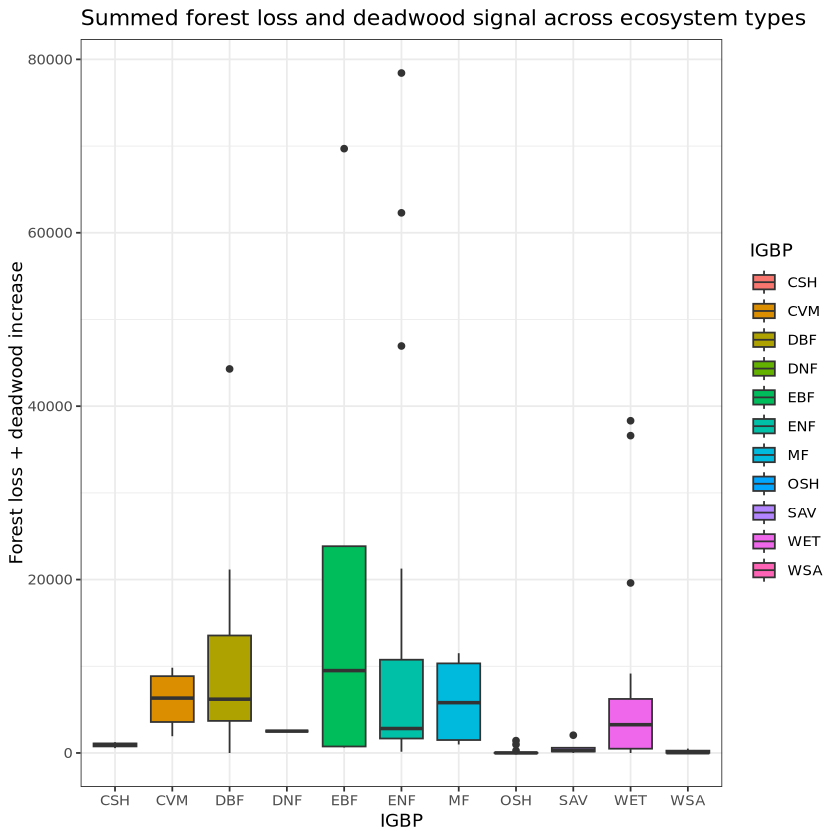

In [8]:
ggplot(site_sum, aes(x = IGBP, y = disturbance_sum, fill = IGBP)) +
  geom_boxplot() +
  theme_bw(base_size = 11) +
  labs(
    title = "Summed forest loss and deadwood signal across ecosystem types",
    x = "IGBP",
    y = "Forest loss + deadwood increase"
  )

In [6]:
library(data.table)
library(ggplot2)

# ---------------------------------------------------------
# 1) Load SHAP per-site table (NO MEMORY)
# ---------------------------------------------------------

shap_per_site <- fread(
  "derived_tables/final_results_3yr/shap_no_memory/shap_per_site_no_memory.csv"
)

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

out_dir <- "derived_tables/final_results_3yr/shap_no_memory"

# ---------------------------------------------------------
# 2) Loop over all EFPs
# ---------------------------------------------------------

for (resp_use in response_vars) {
  
  cat("\nProcessing:", resp_use, "\n")
  
  plot_dt <- copy(shap_per_site[response == resp_use])
  
  if (nrow(plot_dt) == 0) {
    cat(" -> skipped (no rows)\n")
    next
  }
  
  # -------------------------------------------------------
  # 3) Identify top 30 sites by DEADWOOD importance
  # -------------------------------------------------------
  
  top_sites <- plot_dt[group == "Deadwood"][order(-rel_importance)][1:30, SITE_ID]
  
  # -------------------------------------------------------
  # 4) Build site-level ordering table
  #    ORDER BY HIGH DEADWOOD IMPORTANCE
  # -------------------------------------------------------
  
  site_order_dt <- plot_dt[group == "Deadwood",
    .(SITE_ID, deadwood_rel = rel_importance)
  ][order(deadwood_rel)]
  
  # add stars to top 30
  site_order_dt[, SITE_ID_lab := ifelse(
    SITE_ID %in% top_sites,
    paste0(SITE_ID, " ★"),
    SITE_ID
  )]
  
  # -------------------------------------------------------
  # 5) Attach ordered labels back to full plotting table
  # -------------------------------------------------------
  
  plot_dt <- merge(
    plot_dt,
    site_order_dt[, .(SITE_ID, SITE_ID_lab, deadwood_rel)],
    by = "SITE_ID",
    all.x = TRUE
  )
  
  # factor order
  plot_dt[, SITE_ID_lab := factor(
    SITE_ID_lab,
    levels = site_order_dt$SITE_ID_lab
  )]
  
  # order fill legend
  plot_dt[, group := factor(
    group,
    levels = c("Deadwood", "Meteo", "Traits")
  )]
  
  # -------------------------------------------------------
  # 6) Plot
  # -------------------------------------------------------
  
  p <- ggplot(plot_dt, aes(x = rel_importance, y = SITE_ID_lab, fill = group)) +

  geom_col(width = 0.85) +

  scale_fill_manual(

    values = c(

      "Deadwood" = "#F8766D",

      "Memory"   = "#7CAE00",

      "Meteo"    = "#00BFC4",

      "Traits"   = "#C77CFF"

    )

  ) +

  labs(

    title = paste("Relative SHAP composition per site -", resp_use),

    x = "Relative importance",

    y = "Site",

    fill = "Driver group"

  ) +

  theme_bw(base_size = 11) +

  theme(

    axis.text.y = element_text(size = 6),

    panel.grid.minor = element_blank()

  )
  
  # -------------------------------------------------------
  # 7) Save
  # -------------------------------------------------------
  
  out_file <- file.path(
    out_dir,
    paste0("plot_shap_stacked_per_site_", resp_use, "_ordered_high_deadwood_no_memory.png")
  )
  
  ggsave(
    out_file,
    p,
    width = 9,
    height = 14,
    dpi = 300
  )
  
  cat(" -> saved:", out_file, "\n")
}


Processing: uWUE 
 -> saved: derived_tables/final_results_3yr/shap_no_memory/plot_shap_stacked_per_site_uWUE_ordered_high_deadwood_no_memory.png 

Processing: ETmax 
 -> saved: derived_tables/final_results_3yr/shap_no_memory/plot_shap_stacked_per_site_ETmax_ordered_high_deadwood_no_memory.png 

Processing: GPPsat 
 -> saved: derived_tables/final_results_3yr/shap_no_memory/plot_shap_stacked_per_site_GPPsat_ordered_high_deadwood_no_memory.png 

Processing: NEPmax 
 -> saved: derived_tables/final_results_3yr/shap_no_memory/plot_shap_stacked_per_site_NEPmax_ordered_high_deadwood_no_memory.png 


In [7]:
### with memory
library(data.table)
library(ggplot2)

# ---------------------------------------------------------
# 1) Load SHAP per-site table (WITH MEMORY)
# ---------------------------------------------------------

shap_per_site <- fread("derived_tables/shap_per_site.csv")

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

out_dir <- "derived_tables"

# ---------------------------------------------------------
# 2) Loop over all EFPs
# ---------------------------------------------------------

for (resp_use in response_vars) {
  
  cat("\nProcessing:", resp_use, "\n")
  
  plot_dt <- copy(shap_per_site[response == resp_use])
  
  if (nrow(plot_dt) == 0) {
    cat(" -> skipped (no rows)\n")
    next
  }
  
  # -------------------------------------------------------
  # 3) Identify top 30 sites by DEADWOOD importance
  # -------------------------------------------------------
  
  top_sites <- plot_dt[group == "Deadwood"][order(-rel_importance)][1:30, SITE_ID]
  
  # -------------------------------------------------------
  # 4) Build site-level ordering table
  #    ORDER BY HIGH DEADWOOD IMPORTANCE
  # -------------------------------------------------------
  
  site_order_dt <- plot_dt[group == "Deadwood",
    .(SITE_ID, deadwood_rel = rel_importance)
  ][order(deadwood_rel)]
  
  # add stars to top 30
  site_order_dt[, SITE_ID_lab := ifelse(
    SITE_ID %in% top_sites,
    paste0(SITE_ID, " ★"),
    SITE_ID
  )]
  
  # -------------------------------------------------------
  # 5) Attach ordered labels back to full plotting table
  # -------------------------------------------------------
  
  plot_dt <- merge(
    plot_dt,
    site_order_dt[, .(SITE_ID, SITE_ID_lab, deadwood_rel)],
    by = "SITE_ID",
    all.x = TRUE
  )
  
  # factor order
  plot_dt[, SITE_ID_lab := factor(
    SITE_ID_lab,
    levels = site_order_dt$SITE_ID_lab
  )]
  
  # order fill legend
  plot_dt[, group := factor(
    group,
    levels = c("Deadwood", "Memory", "Meteo", "Traits")
  )]
  
  # -------------------------------------------------------
  # 6) Plot
  # -------------------------------------------------------
  
  p <- ggplot(plot_dt, aes(x = rel_importance, y = SITE_ID_lab, fill = group)) +

  geom_col(width = 0.85) +

  scale_fill_manual(

    values = c(

      "Deadwood" = "#F8766D",

      "Memory"   = "#7CAE00",

      "Meteo"    = "#00BFC4",

      "Traits"   = "#C77CFF"

    )

  ) +

  labs(

    title = paste("Relative SHAP composition per site -", resp_use),

    x = "Relative importance",

    y = "Site",

    fill = "Driver group"

  ) +

  theme_bw(base_size = 11) +

  theme(

    axis.text.y = element_text(size = 6),

    panel.grid.minor = element_blank()

  )
  
  # -------------------------------------------------------
  # 7) Save
  # -------------------------------------------------------
  
  out_file <- file.path(
    out_dir,
    paste0("plot_shap_stacked_per_site_", resp_use, "_ordered_high_deadwood.png")
  )
  
  ggsave(
    out_file,
    p,
    width = 9,
    height = 14,
    dpi = 300
  )
  
  cat(" -> saved:", out_file, "\n")
}


Processing: uWUE 
 -> saved: derived_tables/plot_shap_stacked_per_site_uWUE_ordered_high_deadwood.png 

Processing: ETmax 
 -> saved: derived_tables/plot_shap_stacked_per_site_ETmax_ordered_high_deadwood.png 

Processing: GPPsat 
 -> saved: derived_tables/plot_shap_stacked_per_site_GPPsat_ordered_high_deadwood.png 

Processing: NEPmax 
 -> saved: derived_tables/plot_shap_stacked_per_site_NEPmax_ordered_high_deadwood.png 


In [2]:
library(data.table)
library(ggplot2)

# =========================================================
# DELTA RMSE PLOTS: mortality effect
# compare M04 (meteo + traits + forest) vs M02 (meteo + traits)
# positive delta_RMSE = improvement from adding mortality
# mark top 30 disturbed sites with ★
# =========================================================

# ---------------------------------------------------------
# 1) Load predictions
# ---------------------------------------------------------

pred <- fread("derived_tables/EFP_batch_predictions_ALL_3yr.csv")

# metadata
meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, IGBP)]
meta_dt <- unique(meta_dt)

# ---------------------------------------------------------
# 2) Define top 30 disturbed sites
#    here: based on mean annual disturbance intensity
#    = loss_mean_pp_500m + deadwood_increase_mean_pp_500m
# ---------------------------------------------------------

dist_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")

site_dist <- dist_dt[, .(
  disturbance_pct = mean(
    loss_mean_pp_500m + deadwood_increase_mean_pp_500m,
    na.rm = TRUE
  )
), by = SITE_ID]

site_dist <- site_dist[!is.na(disturbance_pct)]

top30_sites <- site_dist[order(-disturbance_pct)][1:30, SITE_ID]

# ---------------------------------------------------------
# 3) Keep only the four raw EFPs
# ---------------------------------------------------------

efp_keep <- c("uWUE", "ETmax", "GPPsat", "NEPmax")
pred <- pred[response %in% efp_keep]

# ---------------------------------------------------------
# 4) Keep only models M02 and M04
#    M02 = meteo + traits
#    M04 = meteo + traits + forest
# ---------------------------------------------------------

pred <- pred[
  grepl("^M02_", model) | grepl("^M04_", model)
]

pred[, model_group := fifelse(
  grepl("^M02_", model), "M02_traits",
  fifelse(grepl("^M04_", model), "M04_traits_forest", NA_character_)
)]

pred <- pred[!is.na(model_group)]

# ---------------------------------------------------------
# 5) Compute RMSE per site x response x model
# ---------------------------------------------------------

rmse_site <- pred[, .(
  RMSE = sqrt(mean((observed - predicted)^2, na.rm = TRUE))
), by = .(SITE_ID, response, model_group)]

# ---------------------------------------------------------
# 6) Reshape wide and compute delta RMSE
#    positive = improvement from adding forest
# ---------------------------------------------------------

rmse_wide <- dcast(
  rmse_site,
  SITE_ID + response ~ model_group,
  value.var = "RMSE"
)

rmse_wide[, delta_RMSE := M02_traits - M04_traits_forest]

# add IGBP
rmse_wide <- merge(rmse_wide, meta_dt, by = "SITE_ID", all.x = TRUE)

# save table
fwrite(rmse_wide, "derived_tables/deltaRMSE_M04_vs_M02_per_site.csv")

# ---------------------------------------------------------
# 7) Create starred labels for top 30 disturbed sites
# ---------------------------------------------------------

rmse_wide[, SITE_ID_star := ifelse(
  SITE_ID %in% top30_sites,
  paste0(SITE_ID, " ★"),
  SITE_ID
)]

# ---------------------------------------------------------
# 8) Reorder SITE_ID within each response for plotting
#    IMPORTANT: make facet-specific labels
# ---------------------------------------------------------

plot_site <- copy(rmse_wide)

# order from good to bad within each response
plot_site <- plot_site[order(response, delta_RMSE)]

# unique label per response-site combo
plot_site[, SITE_ID_facet := paste(response, SITE_ID_star, sep = "___")]

# set factor order using the sorted table above
plot_site[, SITE_ID_facet := factor(SITE_ID_facet, levels = unique(SITE_ID_facet))]

# ---------------------------------------------------------
# 9) Site-level bar plot
# ---------------------------------------------------------

p_site <- ggplot(plot_site, aes(x = delta_RMSE, y = SITE_ID_facet, fill = IGBP)) +
  geom_col(color = "black", linewidth = 0.1) +
  facet_wrap(~response, scales = "free", ncol = 2) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  scale_y_discrete(labels = function(x) sub(".*___", "", x)) +
  labs(
    title = "Effect of tree mortality on model performance",
    x = expression(Delta*RMSE~"(M02 - M04)"),
    y = "Site"
  ) +
  theme_bw(base_size = 11) +
  theme(
    axis.text.y = element_text(size = 6),
    strip.background = element_rect(fill = "grey90"),
    panel.grid.major.y = element_line(colour = "grey90"),
    panel.grid.minor = element_blank()
  )

ggsave(
  "derived_tables/plot_deltaRMSE_per_site_M04_vs_M02_starred.png",
  p_site,
  width = 10,
  height = 12,
  dpi = 300
)

# ---------------------------------------------------------
# 10) IGBP-level boxplot
# ---------------------------------------------------------

p_igbp <- ggplot(rmse_wide, aes(x = IGBP, y = delta_RMSE, fill = IGBP)) +
  geom_boxplot(outlier.shape = 16, outlier.size = 1.8) +
  facet_wrap(~response, scales = "free", ncol = 2) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "Effect of mortality across ecosystem types",
    x = "Ecosystem type",
    y = expression(Delta*RMSE~"(M02 - M04)")
  ) +
  theme_bw(base_size = 11) +
  theme(
    strip.background = element_rect(fill = "grey90"),
    panel.grid.major = element_line(colour = "grey90"),
    panel.grid.minor = element_blank()
  )

ggsave(
  "derived_tables/plot_deltaRMSE_by_IGBP_M04_vs_M02.png",
  p_igbp,
  width = 10,
  height = 8,
  dpi = 300
)

# ---------------------------------------------------------
# 11) Save top30 list too
# ---------------------------------------------------------

fwrite(site_dist[order(disturbance_pct)][1:30],
       "derived_tables/top30_disturbed_sites_used_for_stars.csv")

cat("\nFiles written:\n")
cat("- derived_tables/deltaRMSE_M04_vs_M02_per_site.csv\n")
cat("- derived_tables/plot_deltaRMSE_per_site_M04_vs_M02_starred.png\n")
cat("- derived_tables/plot_deltaRMSE_by_IGBP_M04_vs_M02.png\n")
cat("- derived_tables/top30_disturbed_sites_used_for_stars.csv\n")


Files written:
- derived_tables/deltaRMSE_M04_vs_M02_per_site.csv
- derived_tables/plot_deltaRMSE_per_site_M04_vs_M02_starred.png
- derived_tables/plot_deltaRMSE_by_IGBP_M04_vs_M02.png
- derived_tables/top30_disturbed_sites_used_for_stars.csv


In [1]:
library(data.table)
library(ranger)
library(fastshap)
library(ggplot2)

# =========================================================
# GROUPED SHAP:
# meteo split by driver, traits split by function,
# deadwood split by buffer radius, plus memory
# =========================================================

# ---------------------------------------------------------
# 0) Output folder
# ---------------------------------------------------------

out_dir <- "derived_tables/final_results_3yr/grouped_shap_mechanistic"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# ---------------------------------------------------------
# 1) Load data
# ---------------------------------------------------------

dt <- fread("derived_tables/final_results_3yr/modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer_clean.csv")

cat("Loaded dataset:", dim(dt)[1], "rows x", dim(dt)[2], "cols\n")

# add IGBP if missing
if (!("IGBP" %in% names(dt))) {
  meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, year, IGBP)]
  meta_dt <- unique(meta_dt)
  dt <- merge(dt, meta_dt, by = c("SITE_ID", "year"), all.x = TRUE)
}

cat("Rows after adding IGBP (if needed):", nrow(dt), "\n")

# ---------------------------------------------------------
# 2) Responses
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

# ---------------------------------------------------------
# 3) Predictor groups
# ---------------------------------------------------------

# ---- meteo split by driver
meteo_P   <- grep("^P_(mean|q10|q90)_lag[0-9]+$", names(dt), value = TRUE)
meteo_SW  <- grep("^SW_(mean|q10|q90)_lag[0-9]+$", names(dt), value = TRUE)
meteo_TA  <- grep("^TA_(mean|q10|q90)_lag[0-9]+$", names(dt), value = TRUE)
meteo_VPD <- grep("^VPD_(mean|q10|q90)_lag[0-9]+$", names(dt), value = TRUE)

# ---- memory
memory_vars <- grep("_(anom_lag1|anom_lag2)$", names(dt), value = TRUE)

# ---- traits split by function
trait_hydraulic <- c(
  "gsmax_mean", "P12_mean", "P50_mean", "P88_mean", "rdmax_mean", "WUE_mean", "Rooting depth"
)
trait_leaf_morph <- c(
  "Leaf width", "Leaf area (3114)", "SLA", "Leaf thickness", "Leaf dry mass"
)
trait_leaf_chem <- c(
  "Leaf C", "Leaf N (mass)", "Leaf C/N ratio", "Leaf P", "Leaf N (area)", "Leaf delta 15N"
)
trait_stem <- c(
  "Stem conduit density", "Stem conduit diameter", "SSD"
)

trait_hydraulic <- trait_hydraulic[trait_hydraulic %in% names(dt)]
trait_leaf_morph <- trait_leaf_morph[trait_leaf_morph %in% names(dt)]
trait_leaf_chem <- trait_leaf_chem[trait_leaf_chem %in% names(dt)]
trait_stem <- trait_stem[trait_stem %in% names(dt)]

# ---- deadwood split by radius
deadwood_100m <- grep("_(100m)$", names(dt), value = TRUE)
deadwood_200m <- grep("_(200m)$", names(dt), value = TRUE)
deadwood_300m <- grep("_(300m)$", names(dt), value = TRUE)
deadwood_400m <- grep("_(400m)$", names(dt), value = TRUE)
deadwood_500m <- grep("_(500m)$", names(dt), value = TRUE)

# keep only deadwood-related vars inside each radius
deadwood_patterns <- c(
  "^forest_mean_pct_",
  "^loss_area_frac_",
  "^loss_mean_pp_",
  "^loss_sum_pp_",
  "^deadwood_mean_pct_",
  "^deadwood_increase_area_frac_",
  "^deadwood_increase_mean_pp_",
  "^deadwood_increase_sum_pp_"
)

keep_deadwood_only <- function(x) {
  x[sapply(x, function(v) any(sapply(deadwood_patterns, function(p) grepl(p, v))))]
}

deadwood_100m <- keep_deadwood_only(deadwood_100m)
deadwood_200m <- keep_deadwood_only(deadwood_200m)
deadwood_300m <- keep_deadwood_only(deadwood_300m)
deadwood_400m <- keep_deadwood_only(deadwood_400m)
deadwood_500m <- keep_deadwood_only(deadwood_500m)

# all predictors used in full model
all_predictors <- unique(c(
  meteo_P, meteo_SW, meteo_TA, meteo_VPD,
  memory_vars,
  trait_hydraulic, trait_leaf_morph, trait_leaf_chem, trait_stem,
  deadwood_100m, deadwood_200m, deadwood_300m, deadwood_400m, deadwood_500m
))

cat("Predictor group sizes:\n")
cat("Meteo_P          :", length(meteo_P), "\n")
cat("Meteo_SW         :", length(meteo_SW), "\n")
cat("Meteo_TA         :", length(meteo_TA), "\n")
cat("Meteo_VPD        :", length(meteo_VPD), "\n")
cat("Memory           :", length(memory_vars), "\n")
cat("Trait_Hydraulic  :", length(trait_hydraulic), "\n")
cat("Trait_LeafMorph  :", length(trait_leaf_morph), "\n")
cat("Trait_LeafChem   :", length(trait_leaf_chem), "\n")
cat("Trait_Stem       :", length(trait_stem), "\n")
cat("Deadwood_100m    :", length(deadwood_100m), "\n")
cat("Deadwood_200m    :", length(deadwood_200m), "\n")
cat("Deadwood_300m    :", length(deadwood_300m), "\n")
cat("Deadwood_400m    :", length(deadwood_400m), "\n")
cat("Deadwood_500m    :", length(deadwood_500m), "\n")

# ---------------------------------------------------------
# 4) Variable -> group map
# ---------------------------------------------------------

group_map <- data.table(variable = all_predictors)

group_map[, group := fifelse(variable %in% meteo_P, "Meteo_P",
                      fifelse(variable %in% meteo_SW, "Meteo_SW",
                      fifelse(variable %in% meteo_TA, "Meteo_TA",
                      fifelse(variable %in% meteo_VPD, "Meteo_VPD",
                      fifelse(variable %in% memory_vars, "Memory",
                      fifelse(variable %in% trait_hydraulic, "Trait_Hydraulic",
                      fifelse(variable %in% trait_leaf_morph, "Trait_LeafMorph",
                      fifelse(variable %in% trait_leaf_chem, "Trait_LeafChem",
                      fifelse(variable %in% trait_stem, "Trait_Stem",
                      fifelse(variable %in% deadwood_100m, "Deadwood_100m",
                      fifelse(variable %in% deadwood_200m, "Deadwood_200m",
                      fifelse(variable %in% deadwood_300m, "Deadwood_300m",
                      fifelse(variable %in% deadwood_400m, "Deadwood_400m",
                      fifelse(variable %in% deadwood_500m, "Deadwood_500m",
                      "Other"))))))))))))))]

# ---------------------------------------------------------
# 5) Function to compute grouped SHAP for one response
# ---------------------------------------------------------

compute_grouped_shap <- function(data_subset,
                                 response_var,
                                 nsim = 10,
                                 num_trees = 500,
                                 min_rows = 50,
                                 min_sites = 10) {
  
  needed_cols <- c("SITE_ID", "year", "IGBP", response_var, all_predictors)
  needed_cols <- needed_cols[needed_cols %in% names(data_subset)]
  
  d <- copy(data_subset)[, ..needed_cols]
  d <- d[complete.cases(d)]
  
  n_rows <- nrow(d)
  n_sites <- uniqueN(d$SITE_ID)
  
  cat("Running grouped SHAP | response =", response_var,
      "| rows =", n_rows,
      "| sites =", n_sites, "\n")
  
  if (n_rows < min_rows || n_sites < min_sites) {
    cat(" -> skipped\n")
    return(NULL)
  }
  
  xvars <- setdiff(names(d), c("SITE_ID", "year", "IGBP", response_var))
  if (length(xvars) == 0) return(NULL)
  
  X <- d[, ..xvars]
  y <- d[[response_var]]
  
  rf_fit <- ranger(
    x = X,
    y = y,
    num.trees = num_trees,
    seed = 42,
    respect.unordered.factors = "order",
    write.forest = TRUE
  )
  
  pred_fun <- function(object, newdata) {
    predict(object, data = newdata)$predictions
  }
  
  shap_mat <- fastshap::explain(
    object = rf_fit,
    X = X,
    pred_wrapper = pred_fun,
    nsim = nsim,
    adjust = TRUE
  )
  
  shap_dt <- as.data.table(shap_mat)
  shap_dt[, SITE_ID := d$SITE_ID]
  
  shap_long <- melt(
    shap_dt,
    id.vars = c("SITE_ID"),
    measure.vars = setdiff(names(shap_dt), "SITE_ID"),
    variable.name = "variable",
    value.name = "shap"
  )
  
  shap_long <- merge(shap_long, group_map, by = "variable", all.x = TRUE)
  
  shap_group <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = .(SITE_ID, group)]
  
  shap_group[, rel_importance := mean_abs_shap / sum(mean_abs_shap), by = SITE_ID]
  shap_group[, response := response_var]
  
  setcolorder(shap_group, c("SITE_ID", "response", "group",
                            "mean_abs_shap", "rel_importance"))
  
  return(shap_group)
}

# ---------------------------------------------------------
# 6) Run for all EFPs
# ---------------------------------------------------------

grouped_shap_list <- list()

for (resp in response_vars) {
  grouped_shap_list[[resp]] <- compute_grouped_shap(
    data_subset = dt,
    response_var = resp,
    nsim = 10,
    num_trees = 500,
    min_rows = 50,
    min_sites = 10
  )
}

grouped_shap <- rbindlist(grouped_shap_list, fill = TRUE)

# ---------------------------------------------------------
# 7) Save tables
# ---------------------------------------------------------

fwrite(grouped_shap, file.path(out_dir, "grouped_shap_per_site_mechanistic.csv"))

grouped_summary <- grouped_shap[, .(
  mean_rel_importance = mean(rel_importance, na.rm = TRUE),
  sd_rel_importance = sd(rel_importance, na.rm = TRUE),
  n_sites = uniqueN(SITE_ID)
), by = .(response, group)]

fwrite(grouped_summary, file.path(out_dir, "grouped_shap_summary_mechanistic.csv"))

# ---------------------------------------------------------
# 8) Order groups for plotting
# ---------------------------------------------------------

group_levels <- c(
  "Meteo_P", "Meteo_SW", "Meteo_TA", "Meteo_VPD",
  "Memory",
  "Trait_Hydraulic", "Trait_LeafMorph", "Trait_LeafChem", "Trait_Stem",
  "Deadwood_100m", "Deadwood_200m", "Deadwood_300m", "Deadwood_400m", "Deadwood_500m"
)

grouped_summary[, group := factor(group, levels = group_levels)]

# ---------------------------------------------------------
# 9) Plot: stacked mean relative importance by EFP
# ---------------------------------------------------------

p <- ggplot(grouped_summary, aes(x = response, y = mean_rel_importance, fill = group)) +
  geom_col() +
  labs(
    title = "Grouped SHAP importance by ecosystem function",
    subtitle = "Meteorology split by driver, traits by function, deadwood by buffer radius",
    x = "",
    y = "Mean relative importance",
    fill = "Predictor group"
  ) +
  theme_bw(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(size = 11)
  )

ggsave(
  file.path(out_dir, "plot_grouped_shap_mechanistic_stacked.png"),
  p,
  width = 12,
  height = 7,
  dpi = 300
)

# ---------------------------------------------------------
# 10) Optional plot: deadwood radius only
# ---------------------------------------------------------

deadwood_radius_summary <- grouped_summary[grepl("^Deadwood_", group)]

p2 <- ggplot(deadwood_radius_summary, aes(x = group, y = mean_rel_importance, fill = group)) +
  geom_col() +
  facet_wrap(~response, scales = "free_y") +
  labs(
    title = "Deadwood SHAP importance by buffer radius",
    x = "",
    y = "Mean relative importance"
  ) +
  theme_bw(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

ggsave(
  file.path(out_dir, "plot_grouped_shap_deadwood_radius.png"),
  p2,
  width = 11,
  height = 7,
  dpi = 300
)

cat("Files written:\n")
cat("-", file.path(out_dir, "grouped_shap_per_site_mechanistic.csv"), "\n")
cat("-", file.path(out_dir, "grouped_shap_summary_mechanistic.csv"), "\n")
cat("-", file.path(out_dir, "plot_grouped_shap_mechanistic_stacked.png"), "\n")
cat("-", file.path(out_dir, "plot_grouped_shap_deadwood_radius.png"), "\n")

Loaded dataset: 156 rows x 367 cols
Rows after adding IGBP (if needed): 156 
Predictor group sizes:
Meteo_P          : 72 
Meteo_SW         : 72 
Meteo_TA         : 72 
Meteo_VPD        : 72 
Memory           : 8 
Trait_Hydraulic  : 7 
Trait_LeafMorph  : 5 
Trait_LeafChem   : 6 
Trait_Stem       : 3 
Deadwood_100m    : 8 
Deadwood_200m    : 8 
Deadwood_300m    : 8 
Deadwood_400m    : 8 
Deadwood_500m    : 8 
Running grouped SHAP | response = uWUE | rows = 156 | sites = 52 
Running grouped SHAP | response = ETmax | rows = 156 | sites = 52 
Running grouped SHAP | response = GPPsat | rows = 156 | sites = 52 
Running grouped SHAP | response = NEPmax | rows = 156 | sites = 52 
Files written:
- derived_tables/final_results_3yr/grouped_shap_mechanistic/grouped_shap_per_site_mechanistic.csv 
- derived_tables/final_results_3yr/grouped_shap_mechanistic/grouped_shap_summary_mechanistic.csv 
- derived_tables/final_results_3yr/grouped_shap_mechanistic/plot_grouped_shap_mechanistic_stacked.png 
- de

In [2]:
library(data.table)
library(ggplot2)

# =========================================================
# PLOT GROUPED SHAP PER SITE FROM SAVED FILE
# =========================================================

# ---------------------------------------------------------
# 1) Paths
# ---------------------------------------------------------

out_dir <- "derived_tables/final_results_3yr/grouped_shap_mechanistic"

grouped_shap <- fread(file.path(out_dir, "grouped_shap_per_site_mechanistic.csv"))

cat("Loaded grouped SHAP table:", dim(grouped_shap)[1], "rows x", dim(grouped_shap)[2], "cols\n")

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

# ---------------------------------------------------------
# 2) Group order
# ---------------------------------------------------------

group_levels <- c(
  "Meteo_P", "Meteo_SW", "Meteo_TA", "Meteo_VPD",
  "Memory",
  "Trait_Hydraulic", "Trait_LeafMorph", "Trait_LeafChem", "Trait_Stem",
  "Deadwood_100m", "Deadwood_200m", "Deadwood_300m", "Deadwood_400m", "Deadwood_500m"
)

grouped_shap[, group := factor(group, levels = group_levels)]

# ---------------------------------------------------------
# 3) Manual colors
# ---------------------------------------------------------

group_colors <- c(
  "Meteo_P" = "#1b9e77",
  "Meteo_SW" = "#66a61e",
  "Meteo_TA" = "#7570b3",
  "Meteo_VPD" = "#e6ab02",
  "Memory" = "#a6761d",
  "Trait_Hydraulic" = "#8dd3c7",
  "Trait_LeafMorph" = "#80b1d3",
  "Trait_LeafChem" = "#bebada",
  "Trait_Stem" = "#fb8072",
  "Deadwood_100m" = "#fdb462",
  "Deadwood_200m" = "#fccde5",
  "Deadwood_300m" = "#bc80bd",
  "Deadwood_400m" = "#ccebc5",
  "Deadwood_500m" = "#ffed6f"
)

# ---------------------------------------------------------
# 4) Loop over responses and save plots
# ---------------------------------------------------------

for (resp_use in response_vars) {
  
  plot_dt <- copy(grouped_shap[response == resp_use])
  
  if (nrow(plot_dt) == 0) {
    cat("Skipping", resp_use, "- no rows found\n")
    next
  }
  
  # order sites by total deadwood importance
  deadwood_order <- plot_dt[grepl("^Deadwood_", group),
    .(deadwood_total = sum(rel_importance, na.rm = TRUE)),
    by = SITE_ID
  ][order(-deadwood_total)]
  
  plot_dt <- merge(
    plot_dt,
    deadwood_order,
    by = "SITE_ID",
    all.x = TRUE
  )
  
  plot_dt[, SITE_ID := factor(SITE_ID, levels = deadwood_order$SITE_ID)]
  
  p_site <- ggplot(plot_dt, aes(x = rel_importance, y = SITE_ID, fill = group)) +
    geom_col(width = 0.85) +
    scale_fill_manual(values = group_colors, drop = FALSE) +
    labs(
      title = paste("Relative SHAP composition per site -", resp_use),
      subtitle = "Ordered by total deadwood importance",
      x = "Relative importance",
      y = "Site",
      fill = "Predictor group"
    ) +
    theme_bw(base_size = 11) +
    theme(
      axis.text.y = element_text(size = 5),
      panel.grid.minor = element_blank()
    )
  
  out_file <- file.path(out_dir, paste0("plot_grouped_shap_per_site_", resp_use, ".png"))
  
  ggsave(
    out_file,
    p_site,
    width = 10,
    height = 14,
    dpi = 300
  )
  
  cat("Saved:", out_file, "\n")
}

Loaded grouped SHAP table: 2912 rows x 5 cols
Saved: derived_tables/final_results_3yr/grouped_shap_mechanistic/plot_grouped_shap_per_site_uWUE.png 
Saved: derived_tables/final_results_3yr/grouped_shap_mechanistic/plot_grouped_shap_per_site_ETmax.png 
Saved: derived_tables/final_results_3yr/grouped_shap_mechanistic/plot_grouped_shap_per_site_GPPsat.png 
Saved: derived_tables/final_results_3yr/grouped_shap_mechanistic/plot_grouped_shap_per_site_NEPmax.png 


In [1]:
library(data.table)
library(ggplot2)

# =========================================================
# PLOT GROUPED SHAP PER SITE
# ordered by top 30 disturbed sites first, then deadwood SHAP
# with borders around each predictor group
# =========================================================

# ---------------------------------------------------------
# 1) Paths
# ---------------------------------------------------------

out_dir <- "derived_tables/final_results_3yr/grouped_shap_mechanistic"

grouped_shap <- fread(file.path(out_dir, "grouped_shap_per_site_mechanistic.csv"))
dist_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")

cat("Loaded grouped SHAP table:", dim(grouped_shap)[1], "rows x", dim(grouped_shap)[2], "cols\n")

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

# ---------------------------------------------------------
# 2) Group order
# ---------------------------------------------------------

group_levels <- c(
  "Meteo_P", "Meteo_SW", "Meteo_TA", "Meteo_VPD",
  "Memory",
  "Trait_Hydraulic", "Trait_LeafMorph", "Trait_LeafChem", "Trait_Stem",
  "Deadwood_100m", "Deadwood_200m", "Deadwood_300m", "Deadwood_400m", "Deadwood_500m"
)

grouped_shap[, group := factor(group, levels = group_levels)]

# ---------------------------------------------------------
# 3) Manual colors
# ---------------------------------------------------------

group_colors <- c(
  "Meteo_P" = "#1b9e77",
  "Meteo_SW" = "#66a61e",
  "Meteo_TA" = "#7570b3",
  "Meteo_VPD" = "#e6ab02",
  "Memory" = "#a6761d",
  "Trait_Hydraulic" = "#8dd3c7",
  "Trait_LeafMorph" = "#80b1d3",
  "Trait_LeafChem" = "#bebada",
  "Trait_Stem" = "#fb8072",
  "Deadwood_100m" = "#fdb462",
  "Deadwood_200m" = "#fccde5",
  "Deadwood_300m" = "#bc80bd",
  "Deadwood_400m" = "#ccebc5",
  "Deadwood_500m" = "#ffed6f"
)

# ---------------------------------------------------------
# 4) Build top 30 disturbed site list
#    disturbance = mean(loss_mean_pp_500m + deadwood_increase_mean_pp_500m)
# ---------------------------------------------------------

if ("site_id" %in% names(dist_dt) && !("SITE_ID" %in% names(dist_dt))) {
  setnames(dist_dt, "site_id", "SITE_ID")
}

dist_summary <- dist_dt[, .(
  disturbance_mean = mean(loss_mean_pp_500m + deadwood_increase_mean_pp_500m, na.rm = TRUE)
), by = SITE_ID]

top30_sites <- dist_summary[order(-disturbance_mean)][1:30, SITE_ID]

# ---------------------------------------------------------
# 5) Loop over responses and save plots
# ---------------------------------------------------------

for (resp_use in response_vars) {
  
  plot_dt <- copy(grouped_shap[response == resp_use])
  
  if (nrow(plot_dt) == 0) {
    cat("Skipping", resp_use, "- no rows found\n")
    next
  }
  
  # total deadwood importance per site
  deadwood_order <- plot_dt[grepl("^Deadwood_", as.character(group)),
    .(deadwood_total = sum(rel_importance, na.rm = TRUE)),
    by = SITE_ID
  ]
  
  # merge disturbance info
  deadwood_order <- merge(deadwood_order, dist_summary, by = "SITE_ID", all.x = TRUE)
  
  # mark top30
  deadwood_order[, top30_flag := SITE_ID %in% top30_sites]
  
  # starred labels
  deadwood_order[, SITE_ID_lab := ifelse(top30_flag, paste0(SITE_ID, " ★"), SITE_ID)]
  
  # order:
  # 1) top 30 disturbed first
  # 2) within each block, by deadwood SHAP importance
  deadwood_order <- deadwood_order[order(-top30_flag, -deadwood_total, -disturbance_mean)]
  
  plot_dt <- merge(
    plot_dt,
    deadwood_order[, .(SITE_ID, SITE_ID_lab, top30_flag, deadwood_total, disturbance_mean)],
    by = "SITE_ID",
    all.x = TRUE
  )
  
  plot_dt[, SITE_ID_lab := factor(SITE_ID_lab, levels = deadwood_order$SITE_ID_lab)]
  
  p_site <- ggplot(plot_dt, aes(x = rel_importance, y = SITE_ID_lab, fill = group)) +
    geom_col(width = 0.88, color = "white", linewidth = 0.25) +
    scale_fill_manual(values = group_colors, drop = FALSE) +
    labs(
      title = paste("Relative SHAP composition per site -", resp_use),
      subtitle = "Top 30 disturbed sites first; ordered by total deadwood importance",
      x = "Relative importance",
      y = "Site",
      fill = "Predictor group"
    ) +
    theme_bw(base_size = 11) +
    theme(
      axis.text.y = element_text(size = 5),
      panel.grid.minor = element_blank()
    )
  
  out_file <- file.path(
    out_dir,
    paste0("plot_grouped_shap_per_site_", resp_use, "_top30first_boxed.png")
  )
  
  ggsave(
    out_file,
    p_site,
    width = 10,
    height = 14,
    dpi = 300
  )
  
  cat("Saved:", out_file, "\n")
}

Loaded grouped SHAP table: 2912 rows x 5 cols
Saved: derived_tables/final_results_3yr/grouped_shap_mechanistic/plot_grouped_shap_per_site_uWUE_top30first_boxed.png 
Saved: derived_tables/final_results_3yr/grouped_shap_mechanistic/plot_grouped_shap_per_site_ETmax_top30first_boxed.png 
Saved: derived_tables/final_results_3yr/grouped_shap_mechanistic/plot_grouped_shap_per_site_GPPsat_top30first_boxed.png 
Saved: derived_tables/final_results_3yr/grouped_shap_mechanistic/plot_grouped_shap_per_site_NEPmax_top30first_boxed.png 


In [2]:
library(data.table)
library(ggplot2)

# =========================================================
# GLOBAL DOT-WHISKER PLOT FROM SAVED GROUPED SHAP
# uses mean relative importance across sites
# whiskers = 10th to 90th percentile across sites
# colors = 4 workflow groups
# =========================================================

# ---------------------------------------------------------
# 1) Load data
# ---------------------------------------------------------

out_dir <- "derived_tables/final_results_3yr/grouped_shap_mechanistic"

grouped_shap <- fread(file.path(out_dir, "grouped_shap_per_site_mechanistic.csv"))

cat("Loaded grouped SHAP table:", dim(grouped_shap)[1], "rows x", dim(grouped_shap)[2], "cols\n")

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

# ---------------------------------------------------------
# 2) Collapse detailed groups into 4 workflow groups
# ---------------------------------------------------------

grouped_shap[, macro_group := fifelse(
  grepl("^Meteo_", group), "Meteorology",
  fifelse(group == "Memory", "Temporal memory",
  fifelse(grepl("^Trait_", group), "Plant traits",
  fifelse(grepl("^Deadwood_", group), "Forest mortality", "Other")))
)]

# ---------------------------------------------------------
# 3) Summarize globally across sites
# ---------------------------------------------------------

global_dw <- grouped_shap[, .(
  mean_rel = mean(rel_importance, na.rm = TRUE),
  q10_rel  = quantile(rel_importance, 0.10, na.rm = TRUE),
  q90_rel  = quantile(rel_importance, 0.90, na.rm = TRUE),
  mean_abs = mean(mean_abs_shap, na.rm = TRUE),
  n_sites  = uniqueN(SITE_ID)
), by = .(response, group, macro_group)]

# ---------------------------------------------------------
# 4) Order groups within each response by mean importance
# ---------------------------------------------------------

global_dw <- global_dw[order(response, mean_rel)]

global_dw[, group_facet := paste(response, group, sep = "___")]
global_dw[, group_facet := factor(group_facet, levels = unique(group_facet))]

# ---------------------------------------------------------
# 5) Colors matching workflow logic
# ---------------------------------------------------------

workflow_cols <- c(
  "Meteorology"    = "#2F5B9A",  # blue
  "Temporal memory"= "#5A3E8E",  # purple
  "Forest mortality" = "#C23B22",# red
  "Plant traits"   = "#5E7F3A"   # green
)

# ---------------------------------------------------------
# 6) Dot-whisker plot for all EFPs
# ---------------------------------------------------------

p_all <- ggplot(global_dw, aes(x = mean_rel, y = group_facet, color = macro_group)) +
  geom_segment(aes(x = q10_rel, xend = q90_rel, y = group_facet, yend = group_facet),
               linewidth = 1) +
  geom_point(aes(size = mean_rel), alpha = 0.9) +
  facet_wrap(~response, scales = "free_y", ncol = 2) +
  scale_y_discrete(labels = function(x) sub(".*___", "", x)) +
  scale_color_manual(values = workflow_cols) +
  scale_size_continuous(name = "Mean relative\nimportance", range = c(2.5, 8)) +
  labs(
    title = "Global grouped SHAP importance by ecosystem function",
    subtitle = "Points show mean relative importance across sites; whiskers show 10th–90th percentile",
    x = "Relative importance",
    y = "",
    color = "Predictor type"
  ) +
  theme_bw(base_size = 12) +
  theme(
    panel.grid.minor = element_blank(),
    axis.text.y = element_text(size = 9),
    strip.background = element_rect(fill = "grey90")
  )

ggsave(
  file.path(out_dir, "plot_global_dotwhisker_grouped_shap_allEFPs.png"),
  p_all,
  width = 13,
  height = 9,
  dpi = 300
)

# ---------------------------------------------------------
# 7) Also save one plot per EFP
# ---------------------------------------------------------

for (resp_use in response_vars) {
  
  plot_dt <- copy(global_dw[response == resp_use])
  
  p_one <- ggplot(plot_dt, aes(x = mean_rel, y = reorder(group, mean_rel), color = macro_group)) +
    geom_segment(aes(x = q10_rel, xend = q90_rel, y = group, yend = group),
                 linewidth = 1) +
    geom_point(aes(size = mean_rel), alpha = 0.9) +
    scale_color_manual(values = workflow_cols) +
    scale_size_continuous(name = "Mean relative\nimportance", range = c(2.5, 8)) +
    labs(
      title = paste(resp_use, "– grouped SHAP importance (dot-whisker)"),
      subtitle = "Points = mean relative importance; whiskers = 10th–90th percentile across sites",
      x = "Relative importance",
      y = "",
      color = "Predictor type"
    ) +
    theme_bw(base_size = 12) +
    theme(
      panel.grid.minor = element_blank(),
      axis.text.y = element_text(size = 10)
    )
  
  ggsave(
    file.path(out_dir, paste0("plot_global_dotwhisker_", resp_use, ".png")),
    p_one,
    width = 11,
    height = 7,
    dpi = 300
  )
}

# ---------------------------------------------------------
# 8) Save summary table
# ---------------------------------------------------------

fwrite(
  global_dw,
  file.path(out_dir, "grouped_shap_global_dotwhisker_summary.csv")
)

cat("Files written:\n")
cat("-", file.path(out_dir, "plot_global_dotwhisker_grouped_shap_allEFPs.png"), "\n")
cat("-", file.path(out_dir, "grouped_shap_global_dotwhisker_summary.csv"), "\n")
for (resp_use in response_vars) {
  cat("-", file.path(out_dir, paste0("plot_global_dotwhisker_", resp_use, ".png")), "\n")
}

Loaded grouped SHAP table: 2912 rows x 5 cols
Files written:
- derived_tables/final_results_3yr/grouped_shap_mechanistic/plot_global_dotwhisker_grouped_shap_allEFPs.png 
- derived_tables/final_results_3yr/grouped_shap_mechanistic/grouped_shap_global_dotwhisker_summary.csv 
- derived_tables/final_results_3yr/grouped_shap_mechanistic/plot_global_dotwhisker_uWUE.png 
- derived_tables/final_results_3yr/grouped_shap_mechanistic/plot_global_dotwhisker_ETmax.png 
- derived_tables/final_results_3yr/grouped_shap_mechanistic/plot_global_dotwhisker_GPPsat.png 
- derived_tables/final_results_3yr/grouped_shap_mechanistic/plot_global_dotwhisker_NEPmax.png 


In [1]:
library(data.table)
library(ranger)
library(fastshap)
library(ggplot2)

# =========================================================
# STEP 4: SHAP WITHOUT MEMORY
# Simple EGU grouping: Meteo / Traits / Deadwood
# =========================================================
out_dir <- "derived_tables/final_results_3yr_EGU"
shap_dir <- file.path(out_dir, "shap_no_memory_simple_groups")
dir.create(shap_dir, recursive = TRUE, showWarnings = FALSE)

dt <- fread(
  "derived_tables/final_results_3yr/modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer_clean.csv"
)

if (!("IGBP" %in% names(dt))) {
  meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, year, IGBP)]
  meta_dt <- unique(meta_dt)
  dt <- merge(dt, meta_dt, by = c("SITE_ID", "year"), all.x = TRUE)
}

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")

deadwood_patterns <- c(
  "^forest_mean_pct_[0-9]+m$",
  "^loss_area_frac_[0-9]+m$",
  "^loss_mean_pp_[0-9]+m$",
  "^loss_sum_pp_[0-9]+m$",
  "^deadwood_mean_pct_[0-9]+m$",
  "^deadwood_increase_area_frac_[0-9]+m$",
  "^deadwood_increase_mean_pp_[0-9]+m$",
  "^deadwood_increase_sum_pp_[0-9]+m$"
)

deadwood_vars <- unique(unlist(lapply(deadwood_patterns, function(p) {
  grep(p, names(dt), value = TRUE)
})))

trait_vars <- trait_vars[trait_vars %in% names(dt)]
lag24_vars <- lag24_vars[lag24_vars %in% names(dt)]
deadwood_vars <- deadwood_vars[deadwood_vars %in% names(dt)]

all_predictors <- unique(c(lag24_vars, trait_vars, deadwood_vars))

group_map <- data.table(variable = all_predictors)

group_map[, group := fifelse(
  variable %in% lag24_vars, "Meteo",
  fifelse(variable %in% trait_vars, "Traits",
          fifelse(variable %in% deadwood_vars, "Deadwood", "Other"))
)]

cat("Meteo vars   :", length(lag24_vars), "\n")
cat("Trait vars   :", length(trait_vars), "\n")
cat("Deadwood vars:", length(deadwood_vars), "\n")

compute_simple_shap <- function(data_subset,
                                response_var,
                                nsim = 5,
                                num_trees = 300) {
  
  needed_cols <- c("SITE_ID", "year", "IGBP", response_var, all_predictors)
  needed_cols <- needed_cols[needed_cols %in% names(data_subset)]
  
  d <- copy(data_subset)[, ..needed_cols]
  d <- d[complete.cases(d)]
  
  cat("Running SHAP without memory |", response_var,
      "| rows:", nrow(d),
      "| sites:", uniqueN(d$SITE_ID), "\n")
  
  xvars <- setdiff(names(d), c("SITE_ID", "year", "IGBP", response_var))
  
  X <- d[, ..xvars]
  y <- d[[response_var]]
  
  rf_fit <- ranger(
    x = X,
    y = y,
    num.trees = num_trees,
    seed = 42,
    respect.unordered.factors = "order",
    write.forest = TRUE
  )
  
  pred_fun <- function(object, newdata) {
    predict(object, data = newdata)$predictions
  }
  
  shap_mat <- fastshap::explain(
    object = rf_fit,
    X = X,
    pred_wrapper = pred_fun,
    nsim = nsim,
    adjust = TRUE
  )
  
  shap_dt <- as.data.table(shap_mat)
  shap_dt[, SITE_ID := d$SITE_ID]
  
  shap_long <- melt(
    shap_dt,
    id.vars = "SITE_ID",
    variable.name = "variable",
    value.name = "shap"
  )
  
  shap_long <- merge(shap_long, group_map, by = "variable", all.x = TRUE)
  
  shap_group <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = .(SITE_ID, group)]
  
  shap_group[, rel_importance := mean_abs_shap / sum(mean_abs_shap), by = SITE_ID]
  shap_group[, response := response_var]
  
  return(shap_group)
}

shap_list <- list()

for (resp in response_vars) {
  
  shap_list[[resp]] <- compute_simple_shap(
    data_subset = dt,
    response_var = resp,
    nsim = 5,
    num_trees = 300
  )
  
  fwrite(
    rbindlist(shap_list, fill = TRUE),
    file.path(shap_dir, "checkpoint_shap_no_memory_simple_groups.csv")
  )
}

shap_simple <- rbindlist(shap_list, fill = TRUE)

fwrite(
  shap_simple,
  file.path(shap_dir, "shap_no_memory_simple_groups_per_site.csv")
)

Meteo vars   : 288 
Trait vars   : 21 
Deadwood vars: 40 
Running SHAP without memory | uWUE | rows: 156 | sites: 52 
Running SHAP without memory | ETmax | rows: 156 | sites: 52 
Running SHAP without memory | GPPsat | rows: 156 | sites: 52 
Running SHAP without memory | NEPmax | rows: 156 | sites: 52 


In [2]:
#### M4shap:
library(data.table)
library(ranger)
library(fastshap)
library(ggplot2)

# =========================================================
# SHAP for M04 model:
# Meteo + Traits + Disturbance current + Disturbance lag1/2/3
# No anomaly memory, no forest context
# =========================================================

out_dir <- "derived_tables/final_results_3yr_multibuffer"
shap_dir <- file.path(out_dir, "shap_M04_meteo_traits_disturbanceLag")
dir.create(shap_dir, recursive = TRUE, showWarnings = FALSE)

# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------

dt <- fread(
  "derived_tables/final_results_3yr/modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer_clean.csv"
)

cat("Loaded dataset:", nrow(dt), "rows x", ncol(dt), "cols\n")

# Add IGBP if missing
if (!("IGBP" %in% names(dt))) {
  meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, year, IGBP)]
  meta_dt <- unique(meta_dt)
  dt <- merge(dt, meta_dt, by = c("SITE_ID", "year"), all.x = TRUE)
}

# ---------------------------------------------------------
# Response variables
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

# ---------------------------------------------------------
# Trait variables
# ---------------------------------------------------------

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

trait_vars <- trait_vars[trait_vars %in% names(dt)]

# ---------------------------------------------------------
# Meteo lag variables
# ---------------------------------------------------------

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")
lag24_vars <- lag24_vars[lag24_vars %in% names(dt)]

# ---------------------------------------------------------
# Disturbance variables
# IMPORTANT:
# forest_mean_pct_*m is excluded because it is context, not disturbance
# ---------------------------------------------------------

disturbance_patterns <- c(
  "^loss_area_frac_[0-9]+m$",
  "^loss_mean_pp_[0-9]+m$",
  "^loss_sum_pp_[0-9]+m$",
  "^deadwood_mean_pct_[0-9]+m$",
  "^deadwood_increase_area_frac_[0-9]+m$",
  "^deadwood_increase_mean_pp_[0-9]+m$",
  "^deadwood_increase_sum_pp_[0-9]+m$"
)

disturbance_vars <- unique(unlist(lapply(disturbance_patterns, function(p) {
  grep(p, names(dt), value = TRUE)
})))

disturbance_vars <- disturbance_vars[disturbance_vars %in% names(dt)]

cat("Meteo vars              :", length(lag24_vars), "\n")
cat("Trait vars              :", length(trait_vars), "\n")
cat("Current disturbance vars:", length(disturbance_vars), "\n")

# ---------------------------------------------------------
# Create annual disturbance lags: t-1, t-2, t-3
# safer than shift() because it matches by actual year
# ---------------------------------------------------------

setorder(dt, SITE_ID, year)

disturbance_lag_vars <- character()

for (v in disturbance_vars) {
  
  base_lag <- dt[, .(
    SITE_ID,
    year,
    value = get(v)
  )]
  
  for (lag_year in 1:3) {
    
    lag_name <- paste0(v, "_lag", lag_year, "yr")
    
    tmp <- copy(base_lag)
    tmp[, year := year + lag_year]
    setnames(tmp, "value", lag_name)
    
    dt <- merge(
      dt,
      tmp,
      by = c("SITE_ID", "year"),
      all.x = TRUE
    )
    
    disturbance_lag_vars <- c(disturbance_lag_vars, lag_name)
  }
}

disturbance_lag_vars <- disturbance_lag_vars[disturbance_lag_vars %in% names(dt)]

cat("Lagged disturbance vars :", length(disturbance_lag_vars), "\n")

# ---------------------------------------------------------
# M04 predictors:
# meteo + traits + current disturbance + lagged disturbance
# ---------------------------------------------------------

m04_predictors <- unique(c(
  lag24_vars,
  trait_vars,
  disturbance_vars,
  disturbance_lag_vars
))

m04_predictors <- m04_predictors[m04_predictors %in% names(dt)]

cat("Total M04 predictors:", length(m04_predictors), "\n")

writeLines(m04_predictors, file.path(shap_dir, "vars_M04_predictors_used.txt"))
writeLines(lag24_vars, file.path(shap_dir, "vars_M04_meteo_used.txt"))
writeLines(trait_vars, file.path(shap_dir, "vars_M04_traits_used.txt"))
writeLines(disturbance_vars, file.path(shap_dir, "vars_M04_disturbance_current_used.txt"))
writeLines(disturbance_lag_vars, file.path(shap_dir, "vars_M04_disturbance_lagged_used.txt"))

# ---------------------------------------------------------
# Group map for SHAP
# ---------------------------------------------------------

group_map <- data.table(variable = m04_predictors)

group_map[, group := fifelse(
  variable %in% lag24_vars, "Meteo",
  fifelse(variable %in% trait_vars, "Traits",
          fifelse(variable %in% disturbance_vars, "Disturbance current",
                  fifelse(variable %in% disturbance_lag_vars, "Disturbance legacy", "Other")))
)]

fwrite(group_map, file.path(shap_dir, "M04_SHAP_group_map.csv"))

# ---------------------------------------------------------
# SHAP function
# ---------------------------------------------------------

compute_m04_shap <- function(data_subset,
                             response_var,
                             nsim = 20,
                             num_trees = 500,
                             seed = 42) {
  
  needed_cols <- c("SITE_ID", "year", "IGBP", response_var, m04_predictors)
  needed_cols <- needed_cols[needed_cols %in% names(data_subset)]
  
  d <- copy(data_subset)[, ..needed_cols]
  d <- d[!is.na(get(response_var))]
  d <- d[complete.cases(d[, c(response_var, m04_predictors), with = FALSE])]
  
  cat("\nRunning SHAP for M04 |", response_var,
      "| rows:", nrow(d),
      "| sites:", uniqueN(d$SITE_ID),
      "| predictors:", length(m04_predictors), "\n")
  
  if (nrow(d) < 20) {
    stop("Too few complete rows for SHAP: ", response_var)
  }
  
  xvars <- m04_predictors[m04_predictors %in% names(d)]
  
  X <- d[, ..xvars]
  y <- d[[response_var]]
  
  rf_fit <- ranger(
    x = X,
    y = y,
    num.trees = num_trees,
    seed = seed,
    respect.unordered.factors = "order",
    write.forest = TRUE,
    importance = "permutation"
  )
  
  pred_fun <- function(object, newdata) {
    predict(object, data = newdata)$predictions
  }
  
  set.seed(seed)
  
  shap_mat <- fastshap::explain(
    object = rf_fit,
    X = X,
    pred_wrapper = pred_fun,
    nsim = nsim,
    adjust = TRUE
  )
  
  shap_dt <- as.data.table(shap_mat)
  shap_dt[, row_id := .I]
  shap_dt[, SITE_ID := d$SITE_ID]
  shap_dt[, year := d$year]
  shap_dt[, IGBP := d$IGBP]
  shap_dt[, response := response_var]
  
  shap_long <- melt(
    shap_dt,
    id.vars = c("row_id", "SITE_ID", "year", "IGBP", "response"),
    variable.name = "variable",
    value.name = "shap"
  )
  
  shap_long <- merge(shap_long, group_map, by = "variable", all.x = TRUE)
  
  # variable-level SHAP importance
  shap_variable <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = .(response, variable, group)]
  
  setorder(shap_variable, response, -mean_abs_shap)
  
  # group-level SHAP importance per site
  shap_group_site <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = .(response, SITE_ID, group)]
  
  shap_group_site[, rel_importance := mean_abs_shap / sum(mean_abs_shap, na.rm = TRUE),
                  by = .(response, SITE_ID)]
  
  # group-level SHAP importance overall
  shap_group_overall <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = .(response, group)]
  
  shap_group_overall[, rel_importance := mean_abs_shap / sum(mean_abs_shap, na.rm = TRUE),
                     by = response]
  
  setorder(shap_group_overall, response, -mean_abs_shap)
  
  return(list(
    shap_long = shap_long,
    shap_variable = shap_variable,
    shap_group_site = shap_group_site,
    shap_group_overall = shap_group_overall
  ))
}

# ---------------------------------------------------------
# Run SHAP for all responses
# ---------------------------------------------------------

shap_results <- list()

for (resp in response_vars) {
  
  shap_results[[resp]] <- compute_m04_shap(
    data_subset = dt,
    response_var = resp,
    nsim = 20,
    num_trees = 500,
    seed = 42
  )
  
  # checkpoint after each response
  checkpoint_group <- rbindlist(
    lapply(shap_results, function(x) x$shap_group_site),
    fill = TRUE
  )
  
  fwrite(
    checkpoint_group,
    file.path(shap_dir, "checkpoint_M04_SHAP_group_site.csv")
  )
}

# ---------------------------------------------------------
# Combine outputs
# ---------------------------------------------------------

shap_long_all <- rbindlist(
  lapply(shap_results, function(x) x$shap_long),
  fill = TRUE
)

shap_variable_all <- rbindlist(
  lapply(shap_results, function(x) x$shap_variable),
  fill = TRUE
)

shap_group_site_all <- rbindlist(
  lapply(shap_results, function(x) x$shap_group_site),
  fill = TRUE
)

shap_group_overall_all <- rbindlist(
  lapply(shap_results, function(x) x$shap_group_overall),
  fill = TRUE
)

# ---------------------------------------------------------
# Save SHAP outputs
# ---------------------------------------------------------

fwrite(
  shap_long_all,
  file.path(shap_dir, "M04_SHAP_long_all_variables.csv")
)

fwrite(
  shap_variable_all,
  file.path(shap_dir, "M04_SHAP_variable_importance.csv")
)

fwrite(
  shap_group_site_all,
  file.path(shap_dir, "M04_SHAP_group_importance_per_site.csv")
)

fwrite(
  shap_group_overall_all,
  file.path(shap_dir, "M04_SHAP_group_importance_overall.csv")
)

cat("\n=============================\n")
cat("M04 SHAP completed\n")
cat("=============================\n")

cat("\nOverall group importance:\n")
print(shap_group_overall_all)

Loaded dataset: 156 rows x 367 cols
Meteo vars              : 288 
Trait vars              : 21 
Current disturbance vars: 35 
Lagged disturbance vars : 105 
Total M04 predictors: 449 

Running SHAP for M04 | uWUE | rows: 33 | sites: 18 | predictors: 449 

Running SHAP for M04 | ETmax | rows: 33 | sites: 18 | predictors: 449 

Running SHAP for M04 | GPPsat | rows: 33 | sites: 18 | predictors: 449 

Running SHAP for M04 | NEPmax | rows: 33 | sites: 18 | predictors: 449 

M04 SHAP completed

Overall group importance:
    response               group mean_abs_shap rel_importance
      <char>              <char>         <num>          <num>
 1:     uWUE              Traits  1.406692e-02     0.70633662
 2:     uWUE               Meteo  3.427472e-03     0.17210228
 3:     uWUE  Disturbance legacy  1.372103e-03     0.06889684
 4:     uWUE Disturbance current  1.048826e-03     0.05266426
 5:    ETmax              Traits  5.284234e-04     0.67553276
 6:    ETmax               Meteo  1.737976e-0

In [3]:
library(data.table)
library(ranger)
library(fastshap)
library(ggplot2)

# =========================================================
# SHAP for M04 model:
# Meteo + Traits + Disturbance current + Disturbance lag1/2/3
# No anomaly memory, no forest context
#
# Important:
# Predictor NAs are median-imputed for SHAP so that sites are not lost
# because of complete-case filtering across 449 predictors.
# =========================================================

out_dir <- "derived_tables/final_results_3yr_multibuffer"
shap_dir <- file.path(out_dir, "shap_M04_meteo_traits_disturbanceLag_imputed")
dir.create(shap_dir, recursive = TRUE, showWarnings = FALSE)

# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------

dt <- fread(
  "derived_tables/final_results_3yr/modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer_clean.csv"
)

cat("Loaded dataset:", nrow(dt), "rows x", ncol(dt), "cols\n")

# Add IGBP if missing
if (!("IGBP" %in% names(dt))) {
  meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, year, IGBP)]
  meta_dt <- unique(meta_dt)
  dt <- merge(dt, meta_dt, by = c("SITE_ID", "year"), all.x = TRUE)
}

# ---------------------------------------------------------
# Response variables
# ---------------------------------------------------------

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

# ---------------------------------------------------------
# Trait variables
# ---------------------------------------------------------

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

trait_vars <- trait_vars[trait_vars %in% names(dt)]

# ---------------------------------------------------------
# Meteo lag variables
# ---------------------------------------------------------

lag24_vars <- readLines("derived_tables/vars_meteo_lag24_master_3yr.txt")
lag24_vars <- lag24_vars[lag24_vars %in% names(dt)]

# ---------------------------------------------------------
# Disturbance variables
# forest_mean_pct_*m is excluded because it is context,
# not disturbance.
# ---------------------------------------------------------

disturbance_patterns <- c(
  "^loss_area_frac_[0-9]+m$",
  "^loss_mean_pp_[0-9]+m$",
  "^loss_sum_pp_[0-9]+m$",
  "^deadwood_mean_pct_[0-9]+m$",
  "^deadwood_increase_area_frac_[0-9]+m$",
  "^deadwood_increase_mean_pp_[0-9]+m$",
  "^deadwood_increase_sum_pp_[0-9]+m$"
)

disturbance_vars <- unique(unlist(lapply(disturbance_patterns, function(p) {
  grep(p, names(dt), value = TRUE)
})))

disturbance_vars <- disturbance_vars[disturbance_vars %in% names(dt)]

cat("Meteo vars              :", length(lag24_vars), "\n")
cat("Trait vars              :", length(trait_vars), "\n")
cat("Current disturbance vars:", length(disturbance_vars), "\n")

# ---------------------------------------------------------
# Create annual disturbance lags: t-1, t-2, t-3
# matched by actual year
# ---------------------------------------------------------

setorder(dt, SITE_ID, year)

disturbance_lag_vars <- character()

for (v in disturbance_vars) {
  
  base_lag <- dt[, .(
    SITE_ID,
    year,
    value = get(v)
  )]
  
  for (lag_year in 1:3) {
    
    lag_name <- paste0(v, "_lag", lag_year, "yr")
    
    tmp <- copy(base_lag)
    tmp[, year := year + lag_year]
    setnames(tmp, "value", lag_name)
    
    dt <- merge(
      dt,
      tmp,
      by = c("SITE_ID", "year"),
      all.x = TRUE
    )
    
    disturbance_lag_vars <- c(disturbance_lag_vars, lag_name)
  }
}

disturbance_lag_vars <- disturbance_lag_vars[disturbance_lag_vars %in% names(dt)]

cat("Lagged disturbance vars :", length(disturbance_lag_vars), "\n")

# ---------------------------------------------------------
# M04 predictors
# ---------------------------------------------------------

m04_predictors <- unique(c(
  lag24_vars,
  trait_vars,
  disturbance_vars,
  disturbance_lag_vars
))

m04_predictors <- m04_predictors[m04_predictors %in% names(dt)]

cat("Total M04 predictors:", length(m04_predictors), "\n")

writeLines(m04_predictors, file.path(shap_dir, "vars_M04_predictors_used.txt"))
writeLines(lag24_vars, file.path(shap_dir, "vars_M04_meteo_used.txt"))
writeLines(trait_vars, file.path(shap_dir, "vars_M04_traits_used.txt"))
writeLines(disturbance_vars, file.path(shap_dir, "vars_M04_disturbance_current_used.txt"))
writeLines(disturbance_lag_vars, file.path(shap_dir, "vars_M04_disturbance_lagged_used.txt"))

# ---------------------------------------------------------
# Group map for SHAP
# ---------------------------------------------------------

group_map <- data.table(variable = m04_predictors)

group_map[, group := fifelse(
  variable %in% lag24_vars, "Meteo",
  fifelse(variable %in% trait_vars, "Traits",
          fifelse(variable %in% disturbance_vars, "Disturbance current",
                  fifelse(variable %in% disturbance_lag_vars, "Disturbance legacy", "Other")))
)]

fwrite(group_map, file.path(shap_dir, "M04_SHAP_group_map.csv"))

# ---------------------------------------------------------
# Helper: median-impute predictor NAs
# ---------------------------------------------------------

impute_predictors_median <- function(d, predictors) {
  
  impute_log <- data.table(
    variable = character(),
    n_missing_before = integer(),
    imputed_value = numeric()
  )
  
  for (v in predictors) {
    
    if (!(v %in% names(d))) next
    
    n_miss <- sum(is.na(d[[v]]))
    
    if (n_miss > 0) {
      
      if (is.numeric(d[[v]]) || is.integer(d[[v]])) {
        med_v <- median(d[[v]], na.rm = TRUE)
        if (is.na(med_v)) med_v <- 0
        d[is.na(get(v)), (v) := med_v]
        
        impute_log <- rbind(
          impute_log,
          data.table(
            variable = v,
            n_missing_before = n_miss,
            imputed_value = med_v
          ),
          fill = TRUE
        )
      }
    }
  }
  
  return(list(data = d, log = impute_log))
}

# ---------------------------------------------------------
# SHAP function
# ---------------------------------------------------------

compute_m04_shap <- function(data_subset,
                             response_var,
                             nsim = 20,
                             num_trees = 500,
                             seed = 42) {
  
  needed_cols <- c("SITE_ID", "year", "IGBP", response_var, m04_predictors)
  needed_cols <- needed_cols[needed_cols %in% names(data_subset)]
  
  d <- copy(data_subset)[, ..needed_cols]
  d <- d[!is.na(get(response_var))]
  
  xvars <- m04_predictors[m04_predictors %in% names(d)]
  
  # Median-impute predictors instead of dropping rows
  imp <- impute_predictors_median(d, xvars)
  d <- imp$data
  impute_log <- imp$log
  impute_log[, response := response_var]
  
  # Final safety check
  d <- d[complete.cases(d[, c(response_var, xvars), with = FALSE])]
  
  cat("\nRunning SHAP for M04 |", response_var,
      "| rows:", nrow(d),
      "| sites:", uniqueN(d$SITE_ID),
      "| predictors:", length(xvars), "\n")
  
  if (nrow(d) < 20) {
    stop("Too few rows for SHAP after imputation: ", response_var)
  }
  
  X <- d[, ..xvars]
  y <- d[[response_var]]
  
  rf_fit <- ranger(
    x = X,
    y = y,
    num.trees = num_trees,
    seed = seed,
    respect.unordered.factors = "order",
    write.forest = TRUE,
    importance = "permutation"
  )
  
  pred_fun <- function(object, newdata) {
    predict(object, data = newdata)$predictions
  }
  
  set.seed(seed)
  
  shap_mat <- fastshap::explain(
    object = rf_fit,
    X = X,
    pred_wrapper = pred_fun,
    nsim = nsim,
    adjust = TRUE
  )
  
  shap_dt <- as.data.table(shap_mat)
  shap_dt[, row_id := .I]
  shap_dt[, SITE_ID := d$SITE_ID]
  shap_dt[, year := d$year]
  shap_dt[, IGBP := d$IGBP]
  shap_dt[, response := response_var]
  
  shap_long <- melt(
    shap_dt,
    id.vars = c("row_id", "SITE_ID", "year", "IGBP", "response"),
    variable.name = "variable",
    value.name = "shap"
  )
  
  shap_long <- merge(shap_long, group_map, by = "variable", all.x = TRUE)
  
  shap_variable <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = .(response, variable, group)]
  
  setorder(shap_variable, response, -mean_abs_shap)
  
  shap_group_site <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = .(response, SITE_ID, group)]
  
  shap_group_site[, rel_importance := mean_abs_shap / sum(mean_abs_shap, na.rm = TRUE),
                  by = .(response, SITE_ID)]
  
  shap_group_overall <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = .(response, group)]
  
  shap_group_overall[, rel_importance := mean_abs_shap / sum(mean_abs_shap, na.rm = TRUE),
                     by = response]
  
  setorder(shap_group_overall, response, -mean_abs_shap)
  
  return(list(
    shap_long = shap_long,
    shap_variable = shap_variable,
    shap_group_site = shap_group_site,
    shap_group_overall = shap_group_overall,
    impute_log = impute_log
  ))
}

# ---------------------------------------------------------
# Run SHAP for all responses
# ---------------------------------------------------------

shap_results <- list()

for (resp in response_vars) {
  
  shap_results[[resp]] <- compute_m04_shap(
    data_subset = dt,
    response_var = resp,
    nsim = 20,
    num_trees = 500,
    seed = 42
  )
  
  checkpoint_group <- rbindlist(
    lapply(shap_results, function(x) x$shap_group_site),
    fill = TRUE
  )
  
  fwrite(
    checkpoint_group,
    file.path(shap_dir, "checkpoint_M04_SHAP_group_site.csv")
  )
}

# ---------------------------------------------------------
# Combine outputs
# ---------------------------------------------------------

shap_long_all <- rbindlist(
  lapply(shap_results, function(x) x$shap_long),
  fill = TRUE
)

shap_variable_all <- rbindlist(
  lapply(shap_results, function(x) x$shap_variable),
  fill = TRUE
)

shap_group_site_all <- rbindlist(
  lapply(shap_results, function(x) x$shap_group_site),
  fill = TRUE
)

shap_group_overall_all <- rbindlist(
  lapply(shap_results, function(x) x$shap_group_overall),
  fill = TRUE
)

impute_log_all <- rbindlist(
  lapply(shap_results, function(x) x$impute_log),
  fill = TRUE
)

# ---------------------------------------------------------
# Save SHAP outputs
# ---------------------------------------------------------

fwrite(
  shap_long_all,
  file.path(shap_dir, "M04_SHAP_long_all_variables.csv")
)

fwrite(
  shap_variable_all,
  file.path(shap_dir, "M04_SHAP_variable_importance.csv")
)

fwrite(
  shap_group_site_all,
  file.path(shap_dir, "M04_SHAP_group_importance_per_site.csv")
)

fwrite(
  shap_group_overall_all,
  file.path(shap_dir, "M04_SHAP_group_importance_overall.csv")
)

fwrite(
  impute_log_all,
  file.path(shap_dir, "M04_SHAP_imputation_log.csv")
)

cat("\n=============================\n")
cat("M04 SHAP completed with median-imputed predictors\n")
cat("=============================\n")

cat("\nOverall group importance:\n")
print(shap_group_overall_all)

cat("\nFiles written to:\n")
cat(shap_dir, "\n")

Loaded dataset: 156 rows x 367 cols
Meteo vars              : 288 
Trait vars              : 21 
Current disturbance vars: 35 
Lagged disturbance vars : 105 
Total M04 predictors: 449 

Running SHAP for M04 | uWUE | rows: 156 | sites: 52 | predictors: 449 

Running SHAP for M04 | ETmax | rows: 156 | sites: 52 | predictors: 449 

Running SHAP for M04 | GPPsat | rows: 156 | sites: 52 | predictors: 449 

Running SHAP for M04 | NEPmax | rows: 156 | sites: 52 | predictors: 449 

M04 SHAP completed with median-imputed predictors

Overall group importance:
    response               group mean_abs_shap rel_importance
      <char>              <char>         <num>          <num>
 1:     uWUE              Traits  1.636340e-02     0.70097586
 2:     uWUE               Meteo  3.765854e-03     0.16132177
 3:     uWUE Disturbance current  2.700277e-03     0.11567456
 4:     uWUE  Disturbance legacy  5.142116e-04     0.02202781
 5:    ETmax              Traits  5.935647e-04     0.64709919
 6:    ETm

In [1]:
library(data.table)
library(ranger)
library(fastshap)

# =========================================================
# SHAP for M04:
# Meteo + Traits + Disturbance
# Disturbance = forest cover + forest loss + deadwood at t, t-1, t-2
# Across all EFPs
# =========================================================

out_dir <- "derived_tables/final_results_3yr_clean_103sites/RF_final_corrected_forest_in_disturbance"
shap_dir <- file.path(out_dir, "shap_M04_meteo_traits_disturbance")
dir.create(shap_dir, recursive = TRUE, showWarnings = FALSE)

dt <- fread(
  "derived_tables/final_results_3yr_clean_103sites/modeldata_83sites_complete_disturbance_t_tminus1_tminus2.csv"
)

cat("Loaded dataset:", nrow(dt), "rows x", ncol(dt), "cols\n")
cat("Sites:", uniqueN(dt$SITE_ID), "\n")

# ---------------------------------------------------------
# Add IGBP if missing
# ---------------------------------------------------------

if (!("IGBP" %in% names(dt))) {
  meta_dt <- fread("derived_tables/modelready_FINAL_3yr.csv")[, .(SITE_ID, year, IGBP)]
  meta_dt <- unique(meta_dt)
  dt <- merge(dt, meta_dt, by = c("SITE_ID", "year"), all.x = TRUE)
}

response_vars <- c("uWUE", "ETmax", "GPPsat", "NEPmax")

# ---------------------------------------------------------
# Meteo predictors: lag01-lag24 from growing-season centre
# ---------------------------------------------------------

lag24_vars <- grep(
  "^(P|TA|SW|VPD)_(mean|q10|q90)_lag[0-9]{2}$",
  names(dt),
  value = TRUE
)

# ---------------------------------------------------------
# Trait predictors
# ---------------------------------------------------------

trait_vars <- c(
  "gsmax_mean","P12_mean","P50_mean","P88_mean","rdmax_mean","WUE_mean",
  "Leaf C","Leaf N (mass)","Leaf width","Leaf C/N ratio","Leaf P",
  "Stem conduit density","Stem conduit diameter",
  "Leaf area (3114)",
  "SLA","SSD","Leaf thickness","Leaf N (area)",
  "Leaf dry mass","Rooting depth","Leaf delta 15N"
)

trait_vars <- trait_vars[trait_vars %in% names(dt)]

# ---------------------------------------------------------
# Disturbance predictors
# forest cover included as disturbance product
# ---------------------------------------------------------

forest_current_vars <- grep(
  "^forest_mean_pct_[0-9]+m$",
  names(dt),
  value = TRUE
)

disturbance_current_vars <- grep(
  "^(loss_area_frac|loss_mean_pp|loss_sum_pp|deadwood_mean_pct|deadwood_increase_area_frac|deadwood_increase_mean_pp|deadwood_increase_sum_pp)_[0-9]+m$",
  names(dt),
  value = TRUE
)

disturbance_lag_vars <- grep(
  "^(loss_area_frac|loss_mean_pp|loss_sum_pp|deadwood_mean_pct|deadwood_increase_area_frac|deadwood_increase_mean_pp|deadwood_increase_sum_pp)_[0-9]+m_lag[12]yr$",
  names(dt),
  value = TRUE
)

disturbance_vars <- c(
  forest_current_vars,
  disturbance_current_vars,
  disturbance_lag_vars
)

m04_predictors <- unique(c(
  lag24_vars,
  trait_vars,
  disturbance_vars
))

m04_predictors <- m04_predictors[m04_predictors %in% names(dt)]

cat("Meteo vars              :", length(lag24_vars), "\n")
cat("Trait vars              :", length(trait_vars), "\n")
cat("Forest cover vars       :", length(forest_current_vars), "\n")
cat("Current disturbance vars:", length(disturbance_current_vars), "\n")
cat("Lagged disturbance vars :", length(disturbance_lag_vars), "\n")
cat("Total M04 predictors    :", length(m04_predictors), "\n")

writeLines(m04_predictors, file.path(shap_dir, "vars_M04_predictors_used.txt"))
writeLines(lag24_vars, file.path(shap_dir, "vars_M04_meteo_used.txt"))
writeLines(trait_vars, file.path(shap_dir, "vars_M04_traits_used.txt"))
writeLines(forest_current_vars, file.path(shap_dir, "vars_M04_forest_cover_used.txt"))
writeLines(disturbance_current_vars, file.path(shap_dir, "vars_M04_disturbance_current_used.txt"))
writeLines(disturbance_lag_vars, file.path(shap_dir, "vars_M04_disturbance_lagged_used.txt"))

# ---------------------------------------------------------
# Group map
# ---------------------------------------------------------

group_map <- data.table(variable = m04_predictors)

group_map[, group := fifelse(
  variable %in% lag24_vars, "Meteo",
  fifelse(variable %in% trait_vars, "Traits",
          fifelse(variable %in% forest_current_vars, "Forest cover",
                  fifelse(variable %in% disturbance_current_vars, "Disturbance current",
                          fifelse(variable %in% disturbance_lag_vars, "Disturbance legacy", "Other"))))
)]

fwrite(group_map, file.path(shap_dir, "M04_SHAP_group_map.csv"))

# ---------------------------------------------------------
# Median imputation helper
# ---------------------------------------------------------

impute_predictors_median <- function(d, predictors) {
  
  impute_log <- data.table(
    variable = character(),
    n_missing_before = integer(),
    imputed_value = numeric()
  )
  
  for (v in predictors) {
    
    n_miss <- sum(is.na(d[[v]]))
    
    if (n_miss > 0 && (is.numeric(d[[v]]) || is.integer(d[[v]]))) {
      
      med_v <- median(d[[v]], na.rm = TRUE)
      if (is.na(med_v)) med_v <- 0
      
      d[is.na(get(v)), (v) := med_v]
      
      impute_log <- rbind(
        impute_log,
        data.table(
          variable = v,
          n_missing_before = n_miss,
          imputed_value = med_v
        ),
        fill = TRUE
      )
    }
  }
  
  list(data = d, log = impute_log)
}

# ---------------------------------------------------------
# SHAP function
# ---------------------------------------------------------

compute_m04_shap <- function(data_subset,
                             response_var,
                             nsim = 20,
                             num_trees = 500,
                             seed = 42) {
  
  needed_cols <- c("SITE_ID", "year", "IGBP", response_var, m04_predictors)
  needed_cols <- needed_cols[needed_cols %in% names(data_subset)]
  
  d <- copy(data_subset)[, ..needed_cols]
  d <- d[!is.na(get(response_var))]
  
  xvars <- m04_predictors[m04_predictors %in% names(d)]
  
  imp <- impute_predictors_median(d, xvars)
  d <- imp$data
  
  impute_log <- imp$log
  impute_log[, response := response_var]
  
  d <- d[complete.cases(d[, c(response_var, xvars), with = FALSE])]
  
  cat("\nRunning SHAP for M04 |", response_var,
      "| rows:", nrow(d),
      "| sites:", uniqueN(d$SITE_ID),
      "| predictors:", length(xvars), "\n")
  
  X <- d[, ..xvars]
  y <- d[[response_var]]
  
  rf_fit <- ranger(
    x = X,
    y = y,
    num.trees = num_trees,
    seed = seed,
    respect.unordered.factors = "order",
    write.forest = TRUE,
    importance = "permutation"
  )
  
  pred_fun <- function(object, newdata) {
    predict(object, data = newdata)$predictions
  }
  
  set.seed(seed)
  
  shap_mat <- fastshap::explain(
    object = rf_fit,
    X = X,
    pred_wrapper = pred_fun,
    nsim = nsim,
    adjust = TRUE
  )
  
  shap_dt <- as.data.table(shap_mat)
  shap_dt[, row_id := .I]
  shap_dt[, SITE_ID := d$SITE_ID]
  shap_dt[, year := d$year]
  shap_dt[, IGBP := d$IGBP]
  shap_dt[, response := response_var]
  
  shap_long <- melt(
    shap_dt,
    id.vars = c("row_id", "SITE_ID", "year", "IGBP", "response"),
    variable.name = "variable",
    value.name = "shap"
  )
  
  shap_long <- merge(shap_long, group_map, by = "variable", all.x = TRUE)
  
  shap_variable <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = .(response, variable, group)]
  
  setorder(shap_variable, response, -mean_abs_shap)
  
  shap_group_site <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = .(response, SITE_ID, group)]
  
  shap_group_site[, rel_importance := mean_abs_shap / sum(mean_abs_shap, na.rm = TRUE),
                  by = .(response, SITE_ID)]
  
  shap_group_overall <- shap_long[, .(
    mean_abs_shap = mean(abs(shap), na.rm = TRUE)
  ), by = .(response, group)]
  
  shap_group_overall[, rel_importance := mean_abs_shap / sum(mean_abs_shap, na.rm = TRUE),
                     by = response]
  
  setorder(shap_group_overall, response, -mean_abs_shap)
  
  list(
    shap_long = shap_long,
    shap_variable = shap_variable,
    shap_group_site = shap_group_site,
    shap_group_overall = shap_group_overall,
    impute_log = impute_log
  )
}

# ---------------------------------------------------------
# Run SHAP across all EFPs
# ---------------------------------------------------------

shap_results <- list()

for (resp in response_vars) {
  
  shap_results[[resp]] <- compute_m04_shap(
    data_subset = dt,
    response_var = resp,
    nsim = 20,
    num_trees = 500,
    seed = 42
  )
  
  checkpoint_group <- rbindlist(
    lapply(shap_results, function(x) x$shap_group_site),
    fill = TRUE
  )
  
  fwrite(
    checkpoint_group,
    file.path(shap_dir, "checkpoint_M04_SHAP_group_site.csv")
  )
}

# ---------------------------------------------------------
# Combine and save outputs
# ---------------------------------------------------------

shap_long_all <- rbindlist(lapply(shap_results, function(x) x$shap_long), fill = TRUE)
shap_variable_all <- rbindlist(lapply(shap_results, function(x) x$shap_variable), fill = TRUE)
shap_group_site_all <- rbindlist(lapply(shap_results, function(x) x$shap_group_site), fill = TRUE)
shap_group_overall_all <- rbindlist(lapply(shap_results, function(x) x$shap_group_overall), fill = TRUE)
impute_log_all <- rbindlist(lapply(shap_results, function(x) x$impute_log), fill = TRUE)

fwrite(shap_long_all, file.path(shap_dir, "M04_SHAP_long_all_variables.csv"))
fwrite(shap_variable_all, file.path(shap_dir, "M04_SHAP_variable_importance.csv"))
fwrite(shap_group_site_all, file.path(shap_dir, "M04_SHAP_group_importance_per_site.csv"))
fwrite(shap_group_overall_all, file.path(shap_dir, "M04_SHAP_group_importance_overall.csv"))
fwrite(impute_log_all, file.path(shap_dir, "M04_SHAP_imputation_log.csv"))

cat("\n=============================\n")
cat("M04 SHAP completed\n")
cat("=============================\n")

print(shap_group_overall_all)

Loaded dataset: 209 rows x 604 cols
Sites: 83 
Meteo vars              : 288 
Trait vars              : 21 
Forest cover vars       : 5 
Current disturbance vars: 35 
Lagged disturbance vars : 70 
Total M04 predictors    : 419 

Running SHAP for M04 | uWUE | rows: 209 | sites: 83 | predictors: 419 

Running SHAP for M04 | ETmax | rows: 209 | sites: 83 | predictors: 419 

Running SHAP for M04 | GPPsat | rows: 209 | sites: 83 | predictors: 419 

Running SHAP for M04 | NEPmax | rows: 209 | sites: 83 | predictors: 419 

M04 SHAP completed
    response               group mean_abs_shap rel_importance
      <char>              <char>         <num>          <num>
 1:     uWUE        Forest cover  1.396216e-02     0.44559016
 2:     uWUE              Traits  1.215691e-02     0.38797717
 3:     uWUE               Meteo  3.416962e-03     0.10904934
 4:     uWUE  Disturbance legacy  9.385251e-04     0.02995221
 5:     uWUE Disturbance current  8.595294e-04     0.02743113
 6:    ETmax             